# QAM16 vs QAM64 amplitude histogram analysis

This notebook visualizes amplitude distributions for QAM16 and QAM64 at SNR = -4, -2, 0, and 2 dB.

It generates:

- Random single-sample amplitude histograms for each modulation/SNR.
- Random single-sample time-domain normalized amplitude plots: `A(t)/mean(A)` versus sample index `t`.
- Random single-sample time-domain raw amplitude plots: `A(t)` versus sample index `t`.
- Average normalized amplitude histograms over all available samples for each modulation/SNR.
- Average time-domain normalized and raw amplitude curves over all samples for each modulation/SNR.
- Overlay plots comparing QAM16 and QAM64.
- CSV files with selected sample indices, histogram values, and summary statistics.
- A zip file containing all exported figures and tables.

Normalization used here:

1. Each IQ window is RMS-normalized, matching the usual dataset preprocessing idea.
2. Amplitude is computed as `A(t) = sqrt(I(t)^2 + Q(t)^2)`.
3. For histogram comparison, amplitude is also converted to relative amplitude: `A_norm(t) = A(t) / mean(A(t))` per 128-sample window.

The relative amplitude view is useful because it removes absolute scale and shows whether one modulation produces more high-amplitude peaks than the other.

In [1]:
# CELL 1: Setup
import os
import sys
import json
import pickle
import shutil
import subprocess
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Image

REPO_URL = "https://github.com/akshlabh/amr-5-class.git"
WORK_DIR = Path("/kaggle/working/amr-5-class")
DATA_PATH = Path("/kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat")

# Clone or update the repo first. Output folders are created only after this.
if not (WORK_DIR / ".git").exists():
    if WORK_DIR.exists():
        shutil.rmtree(WORK_DIR)
    subprocess.run(["git", "clone", REPO_URL, str(WORK_DIR)], check=True)
else:
    subprocess.run(["git", "-C", str(WORK_DIR), "pull"], check=False)

EXP_DIR = WORK_DIR / "experiments" / "qam_amplitude_histograms"
FIG_DIR = EXP_DIR / "figures"
RESULT_DIR = EXP_DIR / "results"

for d in [FIG_DIR, RESULT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

if str(WORK_DIR) not in sys.path:
    sys.path.insert(0, str(WORK_DIR))

print(f"Work dir : {WORK_DIR}")
print(f"Data path: {DATA_PATH}")
print(f"Figures  : {FIG_DIR}")
print(f"Results  : {RESULT_DIR}")

Cloning into '/kaggle/working/amr-5-class'...


Work dir : /kaggle/working/amr-5-class
Data path: /kaggle/input/datasets/gustavopolicarpo/rml201610a-dict/RML2016.10a_dict.dat
Figures  : /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures
Results  : /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/results


In [2]:
# CELL 2: Configuration and helper functions
TARGET_MODS = ["QAM16", "QAM64"]
TARGET_SNRS = [-4, -2, 0, 2]
N_RANDOM_SAMPLES = 3
RANDOM_SEED = 2026
EPS = 1e-10

COLORS = {
    "QAM16": "#1f77b4",  # blue
    "QAM64": "#ff7f0e",  # orange
}

rng = np.random.default_rng(RANDOM_SEED)


def rms_normalize_iq(X):
    """Per-window RMS normalization for IQ samples shaped (N, 2, 128)."""
    X = np.asarray(X, dtype=np.float32)
    rms = np.sqrt(np.mean(X ** 2, axis=(1, 2), keepdims=True))
    return X / (rms + EPS)


def amplitude_from_iq(X):
    """Return amplitude A(t)=sqrt(I^2+Q^2), shape (N, 128)."""
    X = np.asarray(X, dtype=np.float32)
    return np.sqrt(X[:, 0, :] ** 2 + X[:, 1, :] ** 2)


def normalized_amplitude_from_iq(X):
    """Return relative amplitude A(t)/mean(A), shape (N, 128)."""
    X_norm = rms_normalize_iq(X)
    A = amplitude_from_iq(X_norm)
    return A / (np.mean(A, axis=1, keepdims=True) + EPS)


def safe_snr_name(snr):
    return f"snr_{snr:+03d}db".replace("+", "plus_").replace("-", "minus_")


def per_sample_histograms(A, bins):
    """Density histogram for each row of A. Returns shape (N, len(bins)-1)."""
    hists = []
    for row in A:
        hist, _ = np.histogram(row, bins=bins, density=True)
        hists.append(hist)
    return np.asarray(hists, dtype=np.float32)


def compute_summary_stats(A_raw, A_norm):
    """Return scalar summary statistics for raw and normalized amplitude arrays."""
    raw_flat = A_raw.reshape(-1)
    norm_flat = A_norm.reshape(-1)
    power = A_raw ** 2
    par = np.max(power, axis=1) / (np.mean(power, axis=1) + EPS)
    return {
        "raw_mean": float(np.mean(raw_flat)),
        "raw_std": float(np.std(raw_flat)),
        "raw_p95": float(np.percentile(raw_flat, 95)),
        "raw_p99": float(np.percentile(raw_flat, 99)),
        "norm_mean": float(np.mean(norm_flat)),
        "norm_std": float(np.std(norm_flat)),
        "norm_p95": float(np.percentile(norm_flat, 95)),
        "norm_p99": float(np.percentile(norm_flat, 99)),
        "mean_par": float(np.mean(par)),
        "median_par": float(np.median(par)),
        "max_par": float(np.max(par)),
    }

print("Configuration ready")
print(f"Target modulations: {TARGET_MODS}")
print(f"Target SNRs       : {TARGET_SNRS}")
print(f"Random samples/SNR/modulation: {N_RANDOM_SAMPLES}")

Configuration ready
Target modulations: ['QAM16', 'QAM64']
Target SNRs       : [-4, -2, 0, 2]
Random samples/SNR/modulation: 3


In [3]:
# CELL 3: Load RML2016.10a and prepare QAM16/QAM64 amplitude arrays
assert DATA_PATH.exists(), f"Dataset not found: {DATA_PATH}"

with open(DATA_PATH, "rb") as f:
    data = pickle.load(f, encoding="latin1")

available_keys = set(data.keys())
missing = [(m, s) for m in TARGET_MODS for s in TARGET_SNRS if (m, s) not in available_keys]
assert not missing, f"Missing keys in dataset: {missing}"

amp_raw = {}
amp_norm = {}
selected_samples = []
summary_rows = []

for snr in TARGET_SNRS:
    for mod in TARGET_MODS:
        X = np.asarray(data[(mod, snr)], dtype=np.float32)  # expected (1000, 2, 128)
        assert X.ndim == 3 and X.shape[1:] == (2, 128), f"Unexpected shape for {(mod, snr)}: {X.shape}"

        A_raw = amplitude_from_iq(X)
        A_norm = normalized_amplitude_from_iq(X)
        amp_raw[(mod, snr)] = A_raw
        amp_norm[(mod, snr)] = A_norm

        chosen = rng.choice(X.shape[0], size=N_RANDOM_SAMPLES, replace=False)
        for rank, idx in enumerate(chosen, start=1):
            selected_samples.append({
                "modulation": mod,
                "snr_db": snr,
                "sample_rank": rank,
                "sample_index_in_block": int(idx),
            })

        row = {"modulation": mod, "snr_db": snr, "num_windows": int(X.shape[0]), "window_length": int(X.shape[-1])}
        row.update(compute_summary_stats(A_raw, A_norm))
        summary_rows.append(row)

selected_df = pd.DataFrame(selected_samples)
summary_df = pd.DataFrame(summary_rows)

selected_csv = RESULT_DIR / "selected_random_samples.csv"
summary_csv = RESULT_DIR / "amplitude_summary_statistics.csv"
selected_df.to_csv(selected_csv, index=False)
summary_df.to_csv(summary_csv, index=False)

print("Loaded data and computed amplitude arrays")
display(selected_df)
display(summary_df.round(4))
print(f"Saved: {selected_csv}")
print(f"Saved: {summary_csv}")

Loaded data and computed amplitude arrays


,modulation,snr_db,sample_rank,sample_index_in_block
0,QAM16,-4,1,26
1,QAM16,-4,2,850
2,QAM16,-4,3,178
3,QAM64,-4,1,370
4,QAM64,-4,2,466
5,QAM64,-4,3,79
6,QAM16,-2,1,829
7,QAM16,-2,2,789
8,QAM16,-2,3,704
9,QAM64,-2,1,857


,modulation,snr_db,num_windows,window_length,raw_mean,raw_std,raw_p95,raw_p99,norm_mean,norm_std,norm_p95,norm_p99,mean_par,median_par,max_par
0,QAM16,-4,1000,128,0.0078,0.0040,0.0150,0.0184,1.0,0.5109,1.9192,2.3609,5.1665,4.9946,11.0764
1,QAM64,-4,1000,128,0.0078,0.0040,0.0150,0.0185,1.0,0.5123,1.9249,2.3643,5.2104,4.9876,11.3071
2,QAM16,-2,1000,128,0.0078,0.0038,0.0146,0.0176,1.0,0.4882,1.8688,2.2583,4.6879,4.5367,9.9779
3,QAM64,-2,1000,128,0.0078,0.0038,0.0146,0.0177,1.0,0.4916,1.8745,2.2674,4.7810,4.6333,9.0017
4,QAM16,0,1000,128,0.0078,0.0035,0.0139,0.0164,1.0,0.4524,1.7733,2.1008,4.0925,3.9564,7.5701
5,QAM64,0,1000,128,0.0078,0.0036,0.0140,0.0167,1.0,0.4601,1.7929,2.1389,4.1851,4.0750,8.2692
6,QAM16,2,1000,128,0.0078,0.0034,0.0134,0.0156,1.0,0.4315,1.7098,1.9928,3.5860,3.4744,11.7021
7,QAM64,2,1000,128,0.0078,0.0034,0.0135,0.0158,1.0,0.4376,1.7305,2.0266,3.7300,3.5894,8.4016


Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/results/selected_random_samples.csv
Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/results/amplitude_summary_statistics.csv


In [4]:
# CELL 4: Create common histogram bins
all_norm_values = np.concatenate([amp_norm[(mod, snr)].reshape(-1) for snr in TARGET_SNRS for mod in TARGET_MODS])
all_raw_values = np.concatenate([amp_raw[(mod, snr)].reshape(-1) for snr in TARGET_SNRS for mod in TARGET_MODS])

# Use high percentiles for neat axes while avoiding one noisy extreme stretching the plot.
norm_xmax = float(np.percentile(all_norm_values, 99.9))
raw_xmax = float(np.percentile(all_raw_values, 99.9))

norm_bins = np.linspace(0.0, norm_xmax, 80)
raw_bins = np.linspace(0.0, raw_xmax, 80)

settings = {
    "target_modulations": TARGET_MODS,
    "target_snrs_db": TARGET_SNRS,
    "random_seed": RANDOM_SEED,
    "random_samples_per_modulation_snr": N_RANDOM_SAMPLES,
    "normalized_amplitude_definition": "A_norm(t) = A(t) / mean(A(t)) after per-window RMS IQ normalization",
    "norm_histogram_xmax_99_9_percentile": norm_xmax,
    "raw_histogram_xmax_99_9_percentile": raw_xmax,
    "num_bins": int(len(norm_bins) - 1),
}

settings_path = RESULT_DIR / "histogram_settings.json"
with open(settings_path, "w") as f:
    json.dump(settings, f, indent=2)

print(json.dumps(settings, indent=2))
print(f"Saved: {settings_path}")

{
  "target_modulations": [
    "QAM16",
    "QAM64"
  ],
  "target_snrs_db": [
    -4,
    -2,
    0,
    2
  ],
  "random_seed": 2026,
  "random_samples_per_modulation_snr": 3,
  "normalized_amplitude_definition": "A_norm(t) = A(t) / mean(A(t)) after per-window RMS IQ normalization",
  "norm_histogram_xmax_99_9_percentile": 2.6959550380706787,
  "raw_histogram_xmax_99_9_percentile": 0.021062148734927177,
  "num_bins": 79
}
Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/results/histogram_settings.json


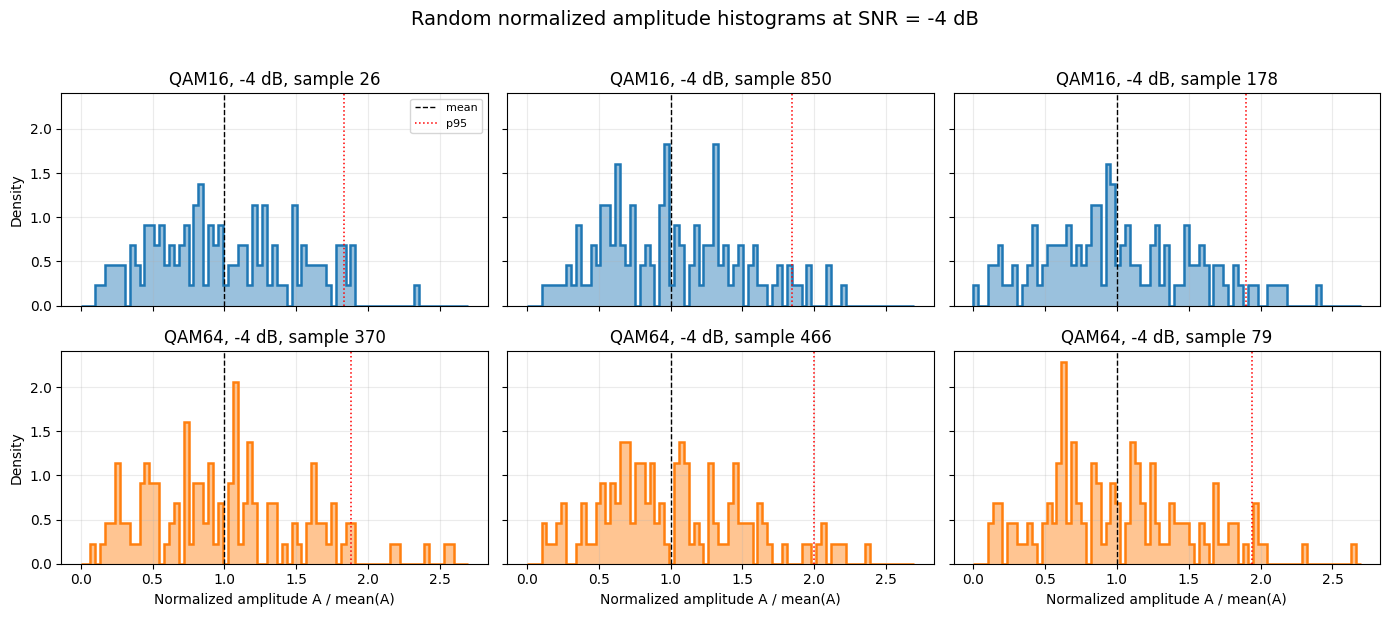

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_04db_random_3_samples_normalized_histograms.png


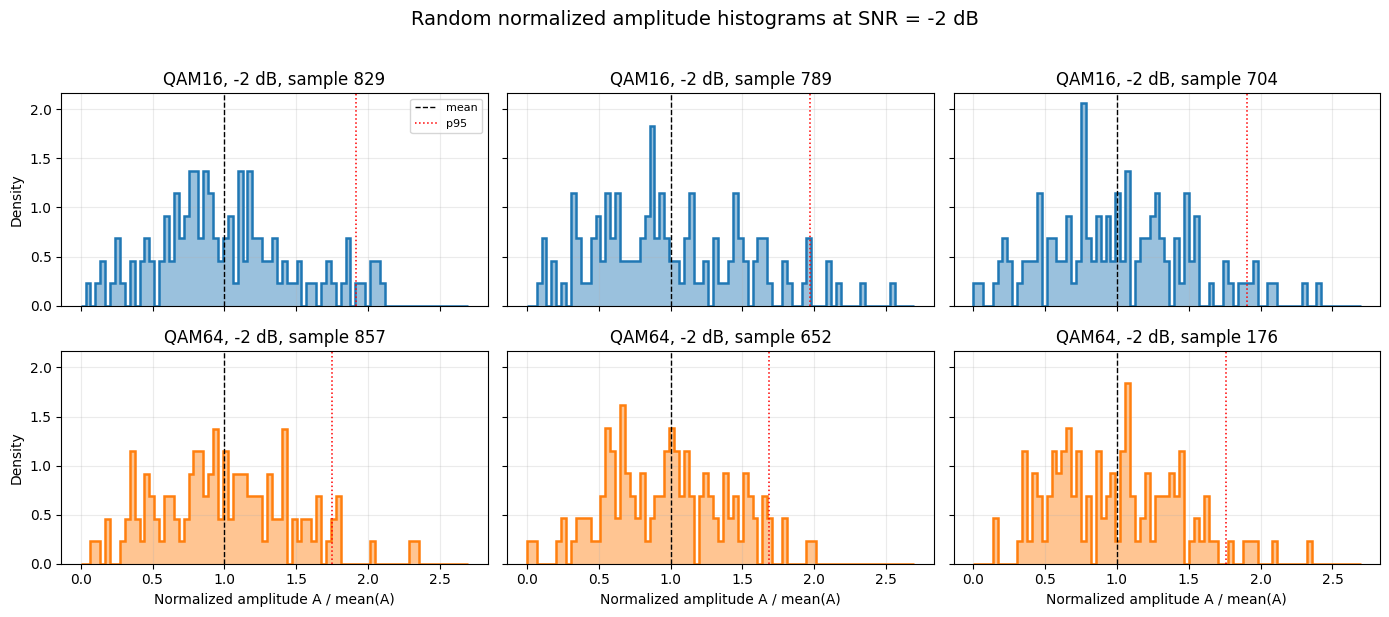

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_02db_random_3_samples_normalized_histograms.png


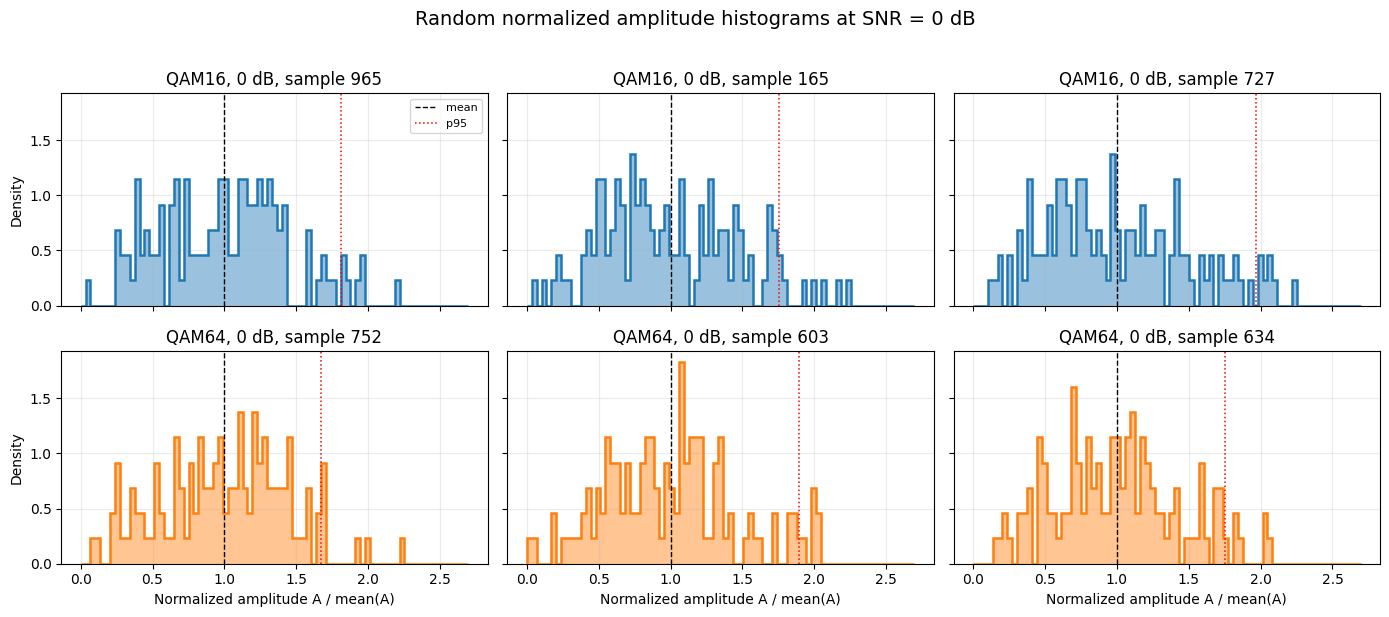

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_00db_random_3_samples_normalized_histograms.png


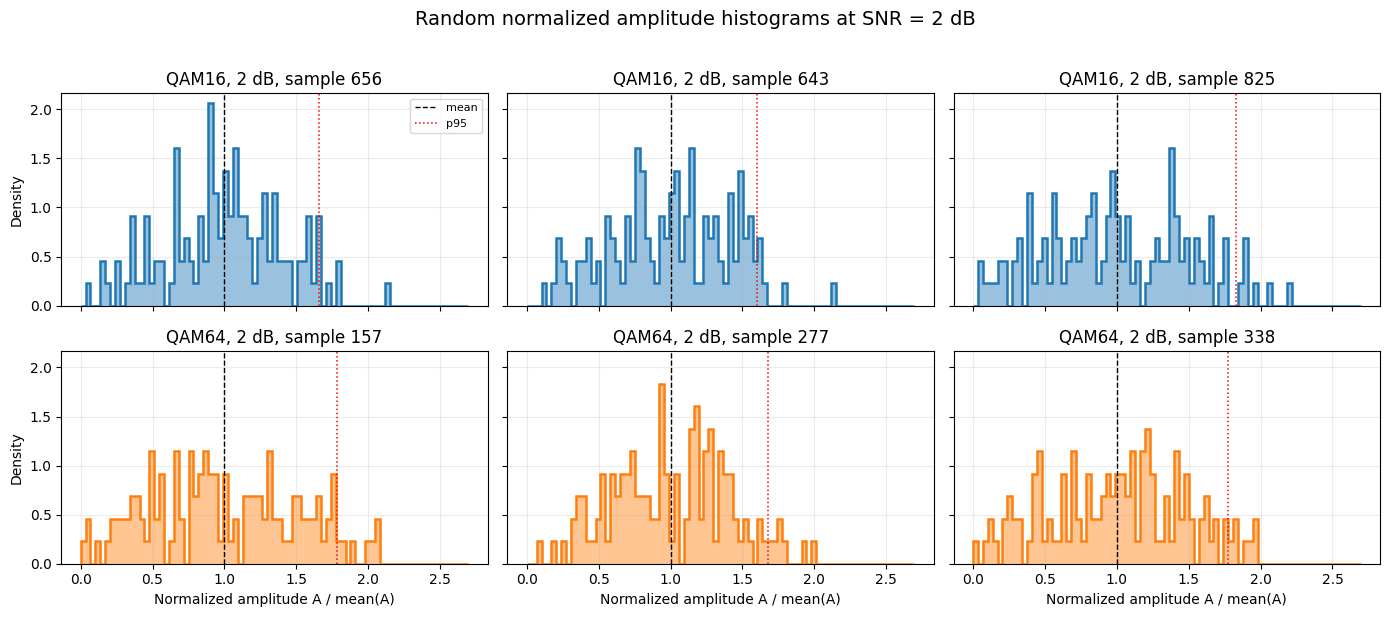

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_02db_random_3_samples_normalized_histograms.png


In [5]:
# CELL 5: Plot random normalized amplitude histograms for 3 samples per class/SNR
for snr in TARGET_SNRS:
    fig, axes = plt.subplots(len(TARGET_MODS), N_RANDOM_SAMPLES, figsize=(14, 6), sharex=True, sharey=True)
    if len(TARGET_MODS) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, mod in enumerate(TARGET_MODS):
        chosen = selected_df[(selected_df["modulation"] == mod) & (selected_df["snr_db"] == snr)].sort_values("sample_rank")
        for c, (_, row) in enumerate(chosen.iterrows()):
            idx = int(row["sample_index_in_block"])
            A = amp_norm[(mod, snr)][idx]
            ax = axes[r, c]
            ax.hist(A, bins=norm_bins, density=True, histtype="stepfilled", alpha=0.45, color=COLORS[mod])
            ax.hist(A, bins=norm_bins, density=True, histtype="step", linewidth=1.8, color=COLORS[mod])
            ax.axvline(np.mean(A), color="black", linestyle="--", linewidth=1.0, label="mean")
            ax.axvline(np.percentile(A, 95), color="red", linestyle=":", linewidth=1.1, label="p95")
            ax.set_title(f"{mod}, {snr} dB, sample {idx}")
            ax.grid(True, alpha=0.25)
            if r == len(TARGET_MODS) - 1:
                ax.set_xlabel("Normalized amplitude A / mean(A)")
            if c == 0:
                ax.set_ylabel("Density")
            if r == 0 and c == 0:
                ax.legend(fontsize=8)

    fig.suptitle(f"Random normalized amplitude histograms at SNR = {snr} dB", fontsize=14, y=1.02)
    fig.tight_layout()
    out_path = FIG_DIR / f"{safe_snr_name(snr)}_random_3_samples_normalized_histograms.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

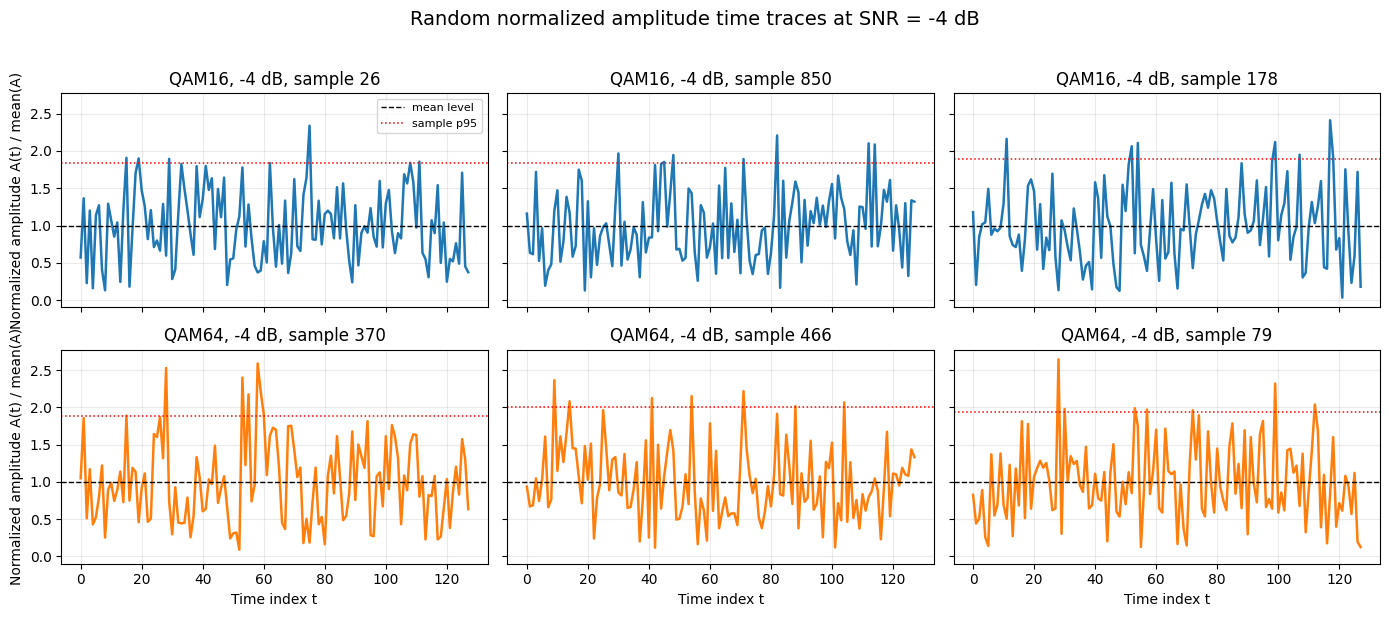

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_04db_random_3_samples_normalized_amplitude_time_traces.png


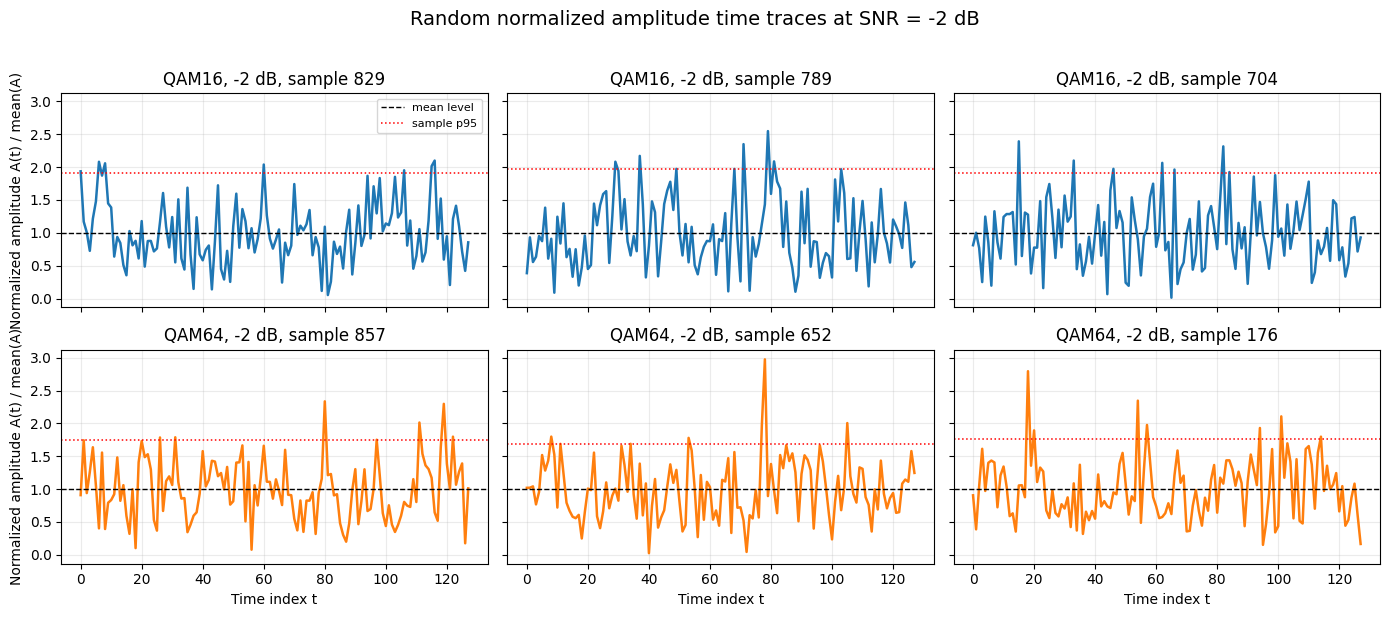

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_02db_random_3_samples_normalized_amplitude_time_traces.png


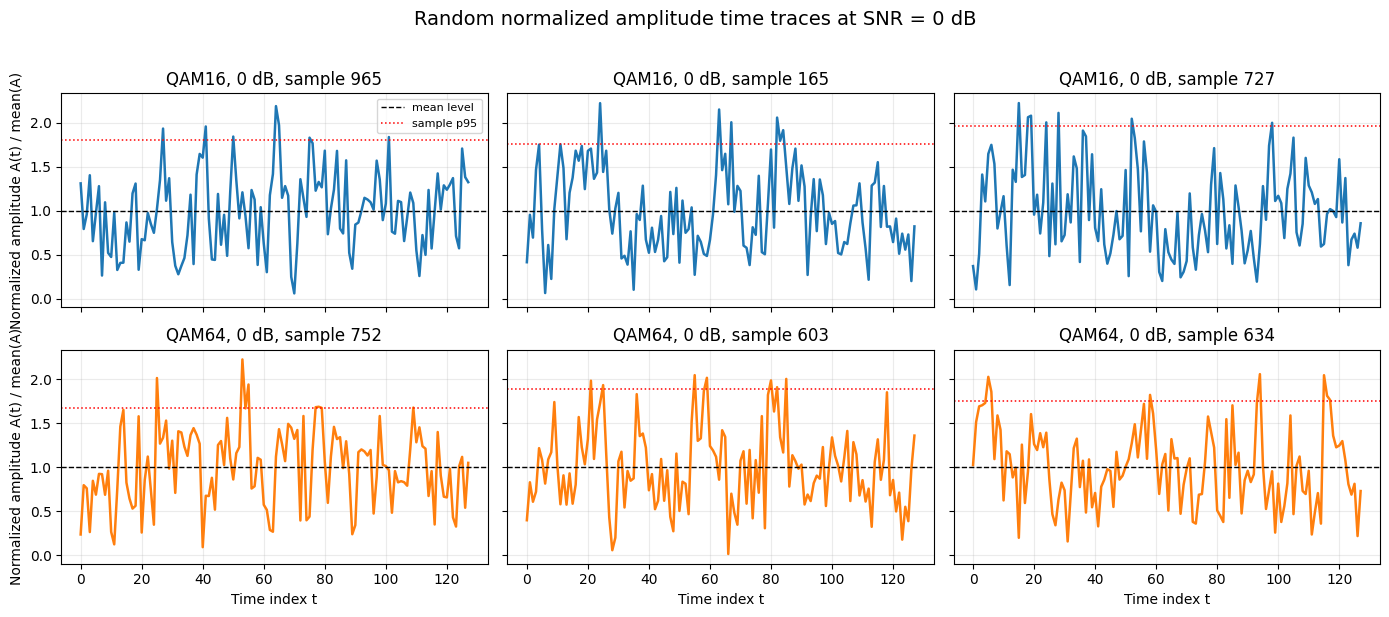

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_00db_random_3_samples_normalized_amplitude_time_traces.png


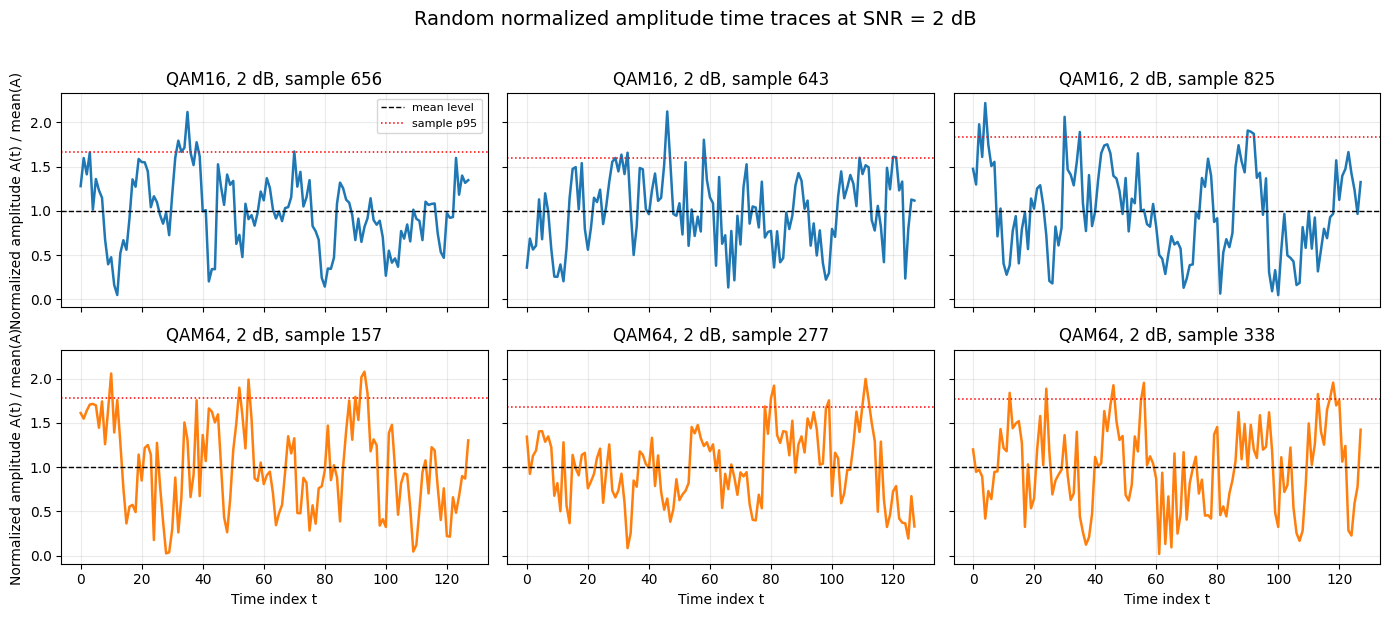

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_02db_random_3_samples_normalized_amplitude_time_traces.png


In [6]:
# CELL 6: Plot random time-domain normalized amplitude A(t) for 3 samples per class/SNR
time_idx = np.arange(128)

for snr in TARGET_SNRS:
    fig, axes = plt.subplots(len(TARGET_MODS), N_RANDOM_SAMPLES, figsize=(14, 6), sharex=True, sharey=True)
    if len(TARGET_MODS) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, mod in enumerate(TARGET_MODS):
        chosen = selected_df[(selected_df["modulation"] == mod) & (selected_df["snr_db"] == snr)].sort_values("sample_rank")
        for c, (_, row) in enumerate(chosen.iterrows()):
            idx = int(row["sample_index_in_block"])
            A = amp_norm[(mod, snr)][idx]
            ax = axes[r, c]
            ax.plot(time_idx, A, color=COLORS[mod], linewidth=1.8)
            ax.axhline(1.0, color="black", linestyle="--", linewidth=1.0, label="mean level")
            ax.axhline(np.percentile(A, 95), color="red", linestyle=":", linewidth=1.1, label="sample p95")
            ax.set_title(f"{mod}, {snr} dB, sample {idx}")
            ax.grid(True, alpha=0.25)
            if r == len(TARGET_MODS) - 1:
                ax.set_xlabel("Time index t")
            if c == 0:
                ax.set_ylabel("Normalized amplitude A(t) / mean(A)")
            if r == 0 and c == 0:
                ax.legend(fontsize=8)

    fig.suptitle(f"Random normalized amplitude time traces at SNR = {snr} dB", fontsize=14, y=1.02)
    fig.tight_layout()
    out_path = FIG_DIR / f"{safe_snr_name(snr)}_random_3_samples_normalized_amplitude_time_traces.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

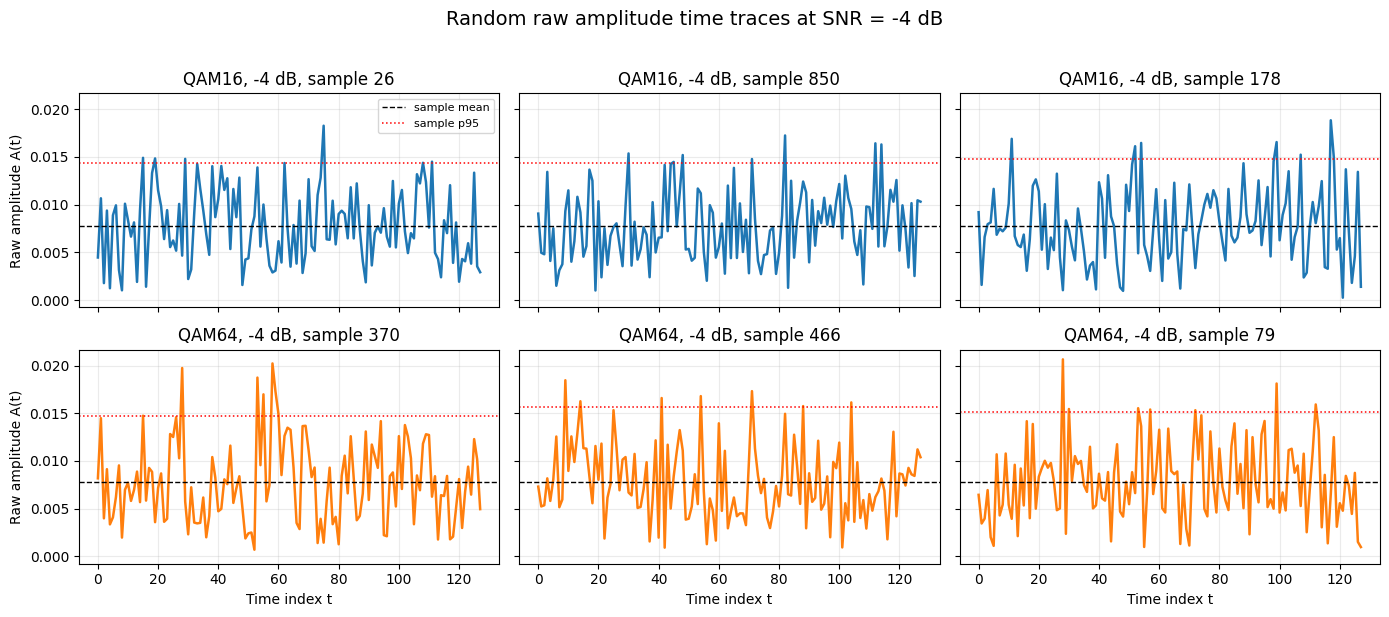

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_04db_random_3_samples_raw_amplitude_time_traces.png


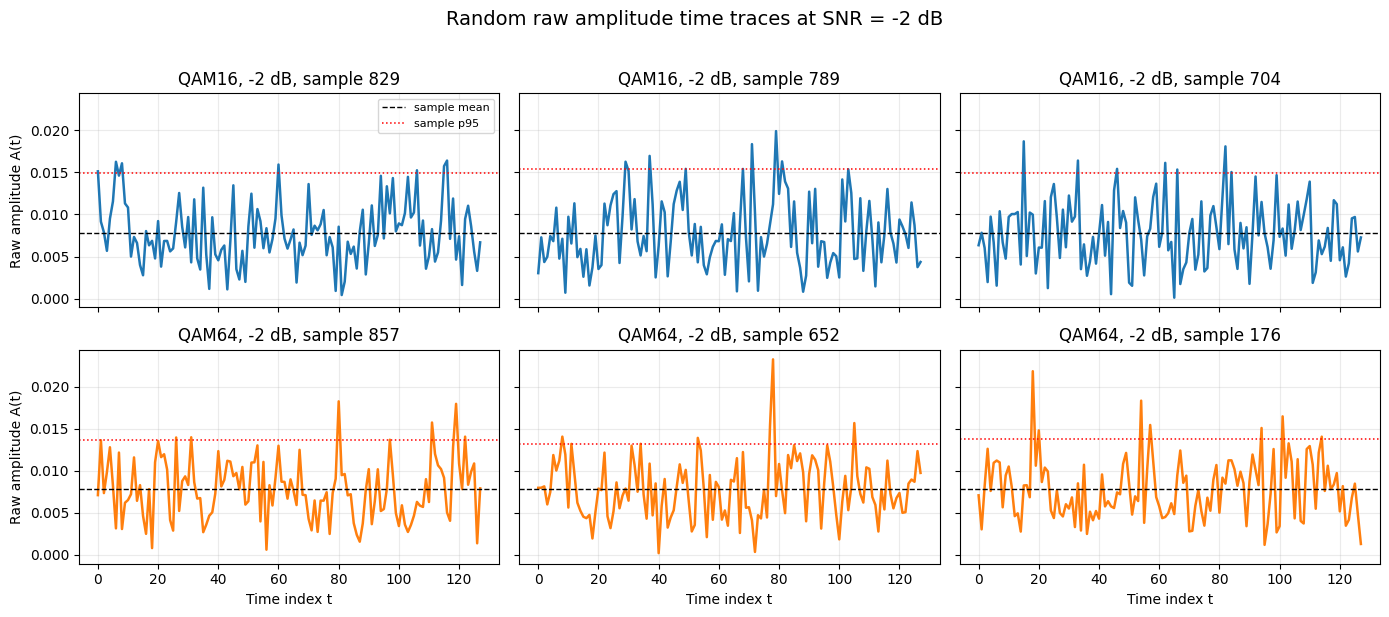

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_02db_random_3_samples_raw_amplitude_time_traces.png


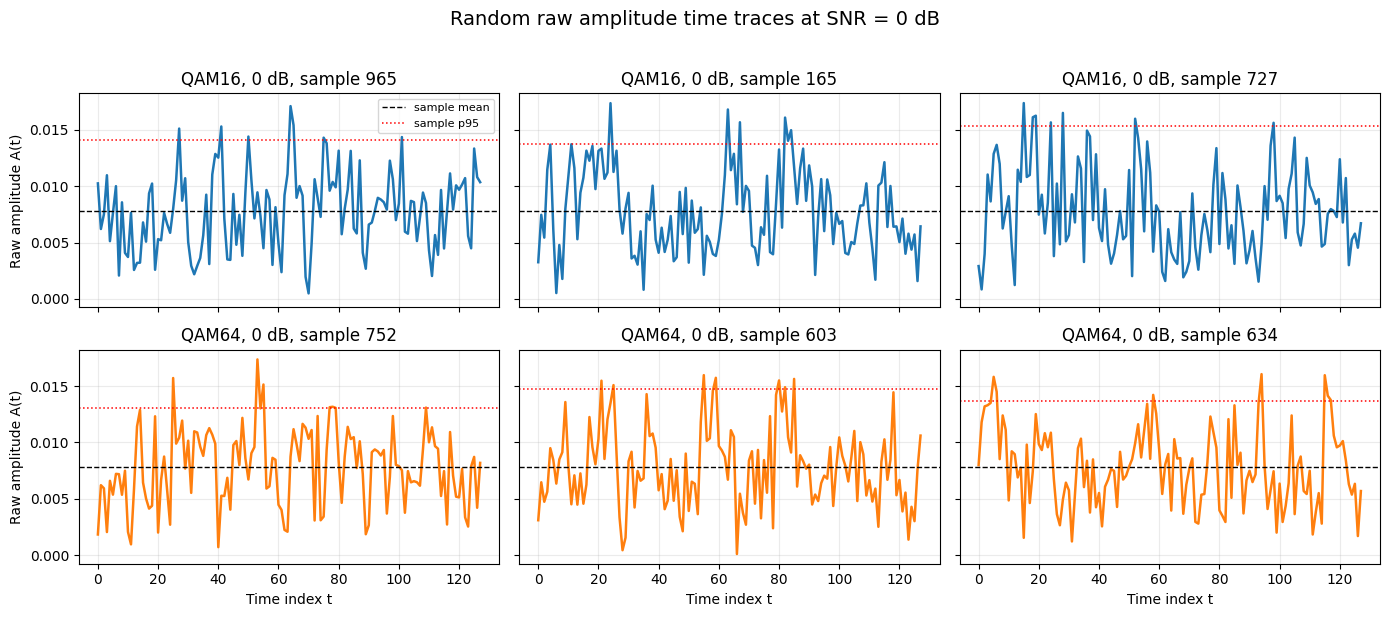

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_00db_random_3_samples_raw_amplitude_time_traces.png


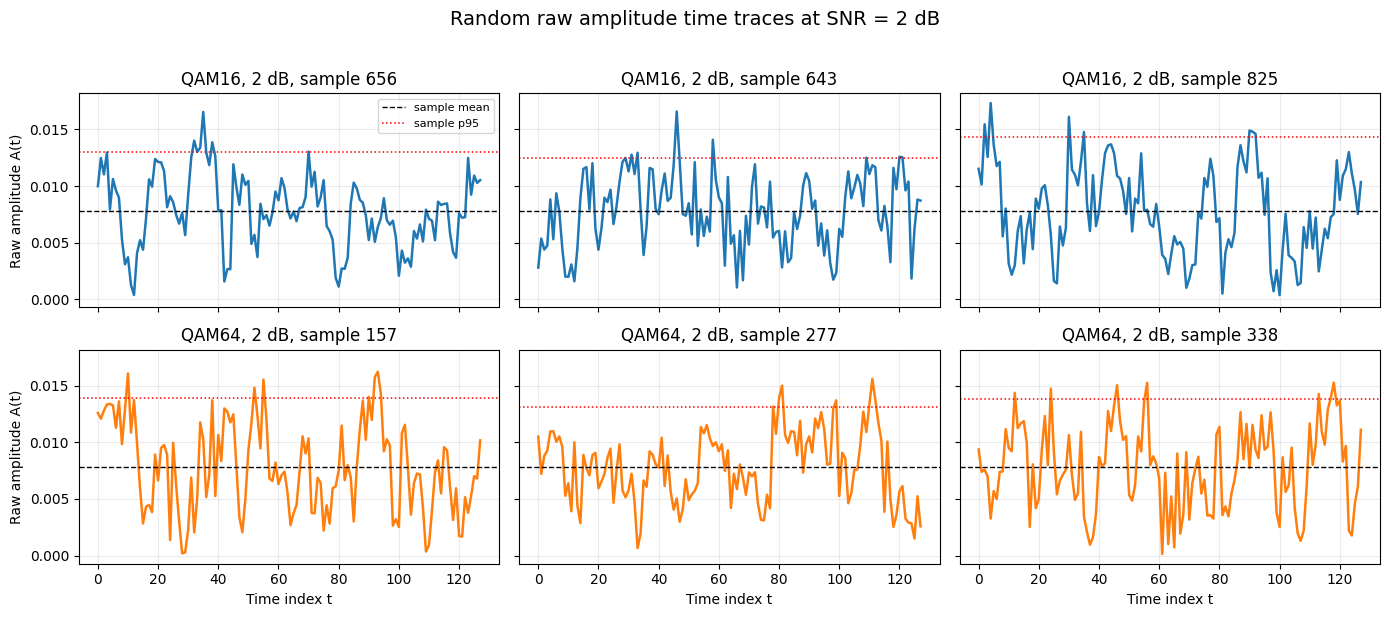

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_02db_random_3_samples_raw_amplitude_time_traces.png


In [7]:
# CELL 7: Plot random raw time-domain amplitude A(t) for 3 samples per class/SNR
for snr in TARGET_SNRS:
    fig, axes = plt.subplots(len(TARGET_MODS), N_RANDOM_SAMPLES, figsize=(14, 6), sharex=True, sharey=True)
    if len(TARGET_MODS) == 1:
        axes = np.expand_dims(axes, axis=0)

    for r, mod in enumerate(TARGET_MODS):
        chosen = selected_df[(selected_df["modulation"] == mod) & (selected_df["snr_db"] == snr)].sort_values("sample_rank")
        for c, (_, row) in enumerate(chosen.iterrows()):
            idx = int(row["sample_index_in_block"])
            A = amp_raw[(mod, snr)][idx]
            ax = axes[r, c]
            ax.plot(time_idx, A, color=COLORS[mod], linewidth=1.8)
            ax.axhline(np.mean(A), color="black", linestyle="--", linewidth=1.0, label="sample mean")
            ax.axhline(np.percentile(A, 95), color="red", linestyle=":", linewidth=1.1, label="sample p95")
            ax.set_title(f"{mod}, {snr} dB, sample {idx}")
            ax.grid(True, alpha=0.25)
            if r == len(TARGET_MODS) - 1:
                ax.set_xlabel("Time index t")
            if c == 0:
                ax.set_ylabel("Raw amplitude A(t)")
            if r == 0 and c == 0:
                ax.legend(fontsize=8)

    fig.suptitle(f"Random raw amplitude time traces at SNR = {snr} dB", fontsize=14, y=1.02)
    fig.tight_layout()
    out_path = FIG_DIR / f"{safe_snr_name(snr)}_random_3_samples_raw_amplitude_time_traces.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

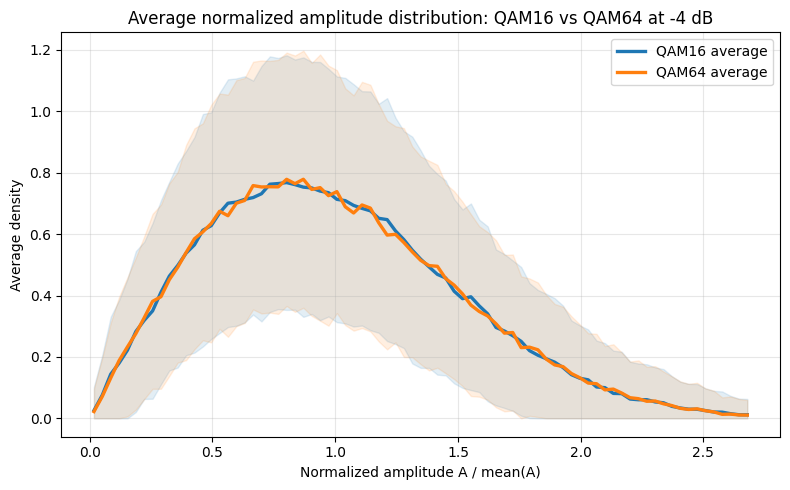

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_04db_average_normalized_overlay.png


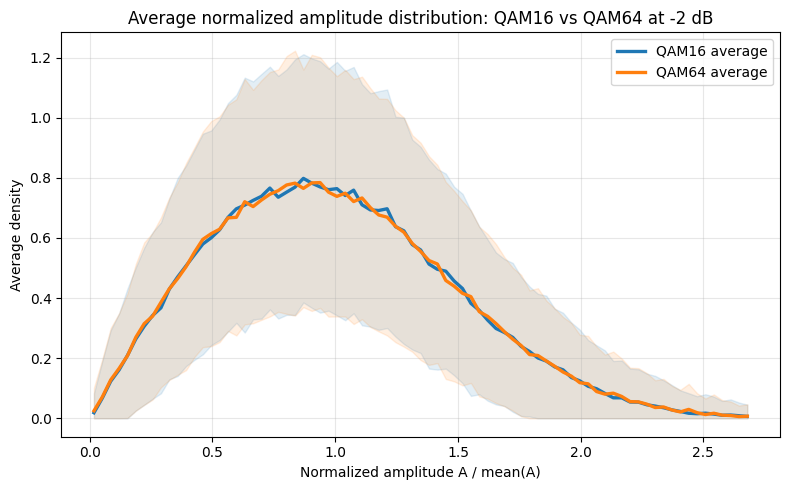

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_02db_average_normalized_overlay.png


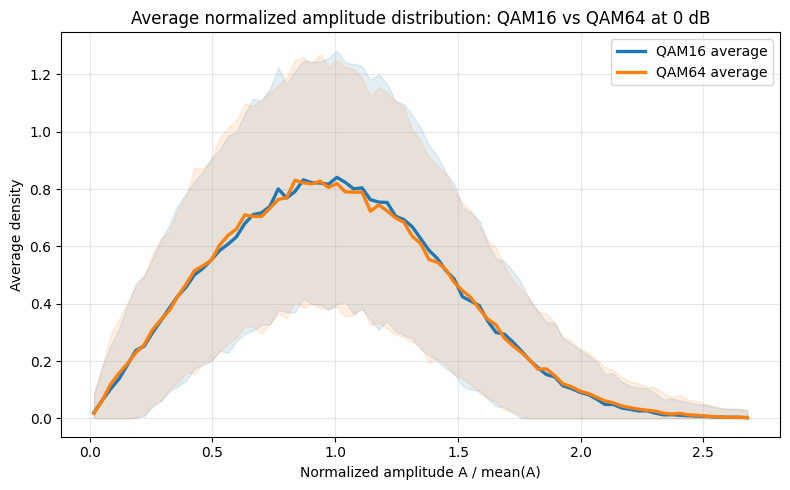

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_00db_average_normalized_overlay.png


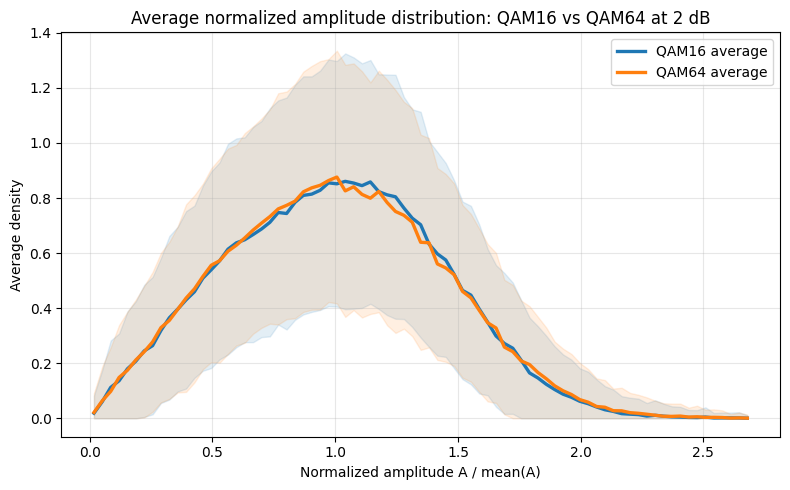

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_02db_average_normalized_overlay.png
Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/results/average_normalized_histogram_values.csv


,snr_db,modulation,bin_left,bin_right,bin_center,mean_density,std_density_across_windows
0,-4,QAM16,0.000000,0.034126,0.017063,0.025484,0.077770
1,-4,QAM16,0.034126,0.068252,0.051189,0.075926,0.130840
2,-4,QAM16,0.068252,0.102378,0.085315,0.143668,0.187117
3,-4,QAM16,0.102378,0.136504,0.119441,0.179902,0.205182
4,-4,QAM16,0.136504,0.170630,0.153567,0.222106,0.232104


In [8]:
# CELL 8: Average normalized histogram overlays for QAM16 vs QAM64
hist_rows = []
centers = 0.5 * (norm_bins[:-1] + norm_bins[1:])

for snr in TARGET_SNRS:
    fig, ax = plt.subplots(figsize=(8, 5))

    for mod in TARGET_MODS:
        H = per_sample_histograms(amp_norm[(mod, snr)], norm_bins)
        mean_h = H.mean(axis=0)
        std_h = H.std(axis=0)

        ax.plot(centers, mean_h, color=COLORS[mod], linewidth=2.4, label=f"{mod} average")
        ax.fill_between(centers, np.maximum(mean_h - std_h, 0), mean_h + std_h, color=COLORS[mod], alpha=0.12)

        for bin_left, bin_right, center, density, std_density in zip(norm_bins[:-1], norm_bins[1:], centers, mean_h, std_h):
            hist_rows.append({
                "snr_db": snr,
                "modulation": mod,
                "bin_left": float(bin_left),
                "bin_right": float(bin_right),
                "bin_center": float(center),
                "mean_density": float(density),
                "std_density_across_windows": float(std_density),
            })

    ax.set_title(f"Average normalized amplitude distribution: QAM16 vs QAM64 at {snr} dB")
    ax.set_xlabel("Normalized amplitude A / mean(A)")
    ax.set_ylabel("Average density")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    out_path = FIG_DIR / f"{safe_snr_name(snr)}_average_normalized_overlay.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

hist_df = pd.DataFrame(hist_rows)
hist_csv = RESULT_DIR / "average_normalized_histogram_values.csv"
hist_df.to_csv(hist_csv, index=False)
print(f"Saved: {hist_csv}")
display(hist_df.head())

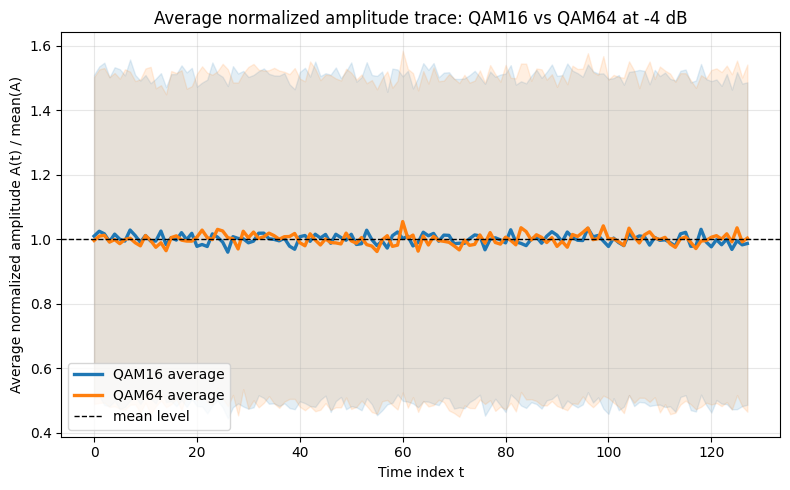

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_04db_average_normalized_amplitude_time_trace.png


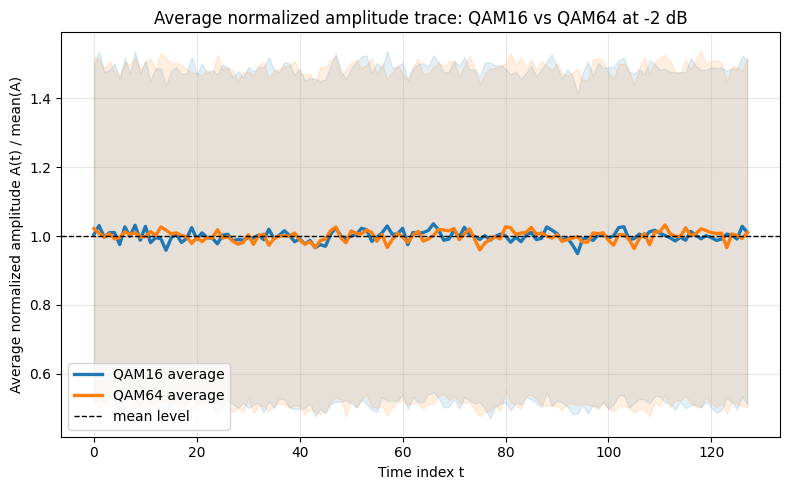

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_02db_average_normalized_amplitude_time_trace.png


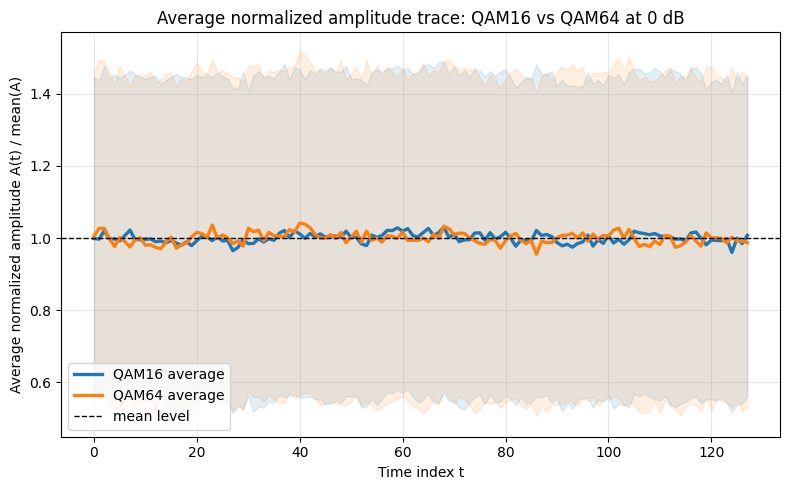

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_00db_average_normalized_amplitude_time_trace.png


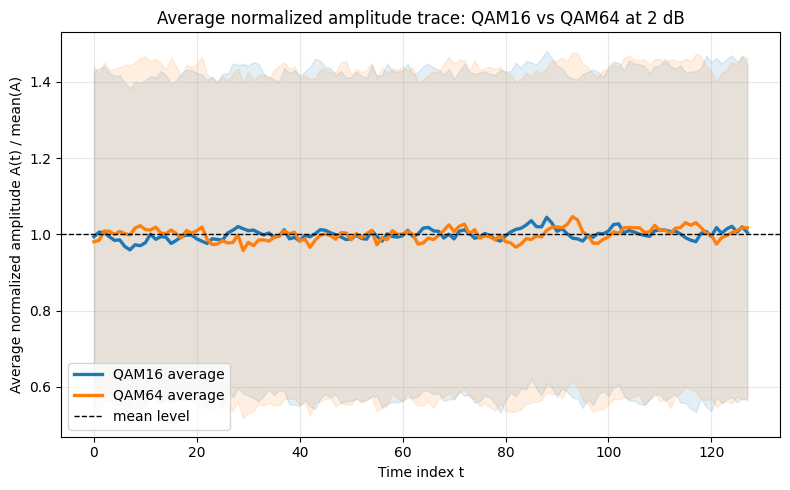

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_02db_average_normalized_amplitude_time_trace.png
Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/results/average_normalized_amplitude_time_trace_values.csv


,snr_db,modulation,time_index,mean_normalized_amplitude,std_normalized_amplitude
0,-4,QAM16,0,1.009658,0.500512
1,-4,QAM16,1,1.024755,0.511211
2,-4,QAM16,2,1.016810,0.530936
3,-4,QAM16,3,0.992394,0.510378
4,-4,QAM16,4,1.015873,0.517644


In [9]:
# CELL 9: Average time-domain normalized amplitude A(t) overlays for QAM16 vs QAM64
at_rows = []

for snr in TARGET_SNRS:
    fig, ax = plt.subplots(figsize=(8, 5))

    for mod in TARGET_MODS:
        A = amp_norm[(mod, snr)]
        mean_curve = A.mean(axis=0)
        std_curve = A.std(axis=0)

        ax.plot(time_idx, mean_curve, color=COLORS[mod], linewidth=2.4, label=f"{mod} average")
        ax.fill_between(time_idx, mean_curve - std_curve, mean_curve + std_curve, color=COLORS[mod], alpha=0.12)

        for t, mean_value, std_value in zip(time_idx, mean_curve, std_curve):
            at_rows.append({
                "snr_db": snr,
                "modulation": mod,
                "time_index": int(t),
                "mean_normalized_amplitude": float(mean_value),
                "std_normalized_amplitude": float(std_value),
            })

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.0, label="mean level")
    ax.set_title(f"Average normalized amplitude trace: QAM16 vs QAM64 at {snr} dB")
    ax.set_xlabel("Time index t")
    ax.set_ylabel("Average normalized amplitude A(t) / mean(A)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    out_path = FIG_DIR / f"{safe_snr_name(snr)}_average_normalized_amplitude_time_trace.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

at_df = pd.DataFrame(at_rows)
at_csv = RESULT_DIR / "average_normalized_amplitude_time_trace_values.csv"
at_df.to_csv(at_csv, index=False)
print(f"Saved: {at_csv}")
display(at_df.head())

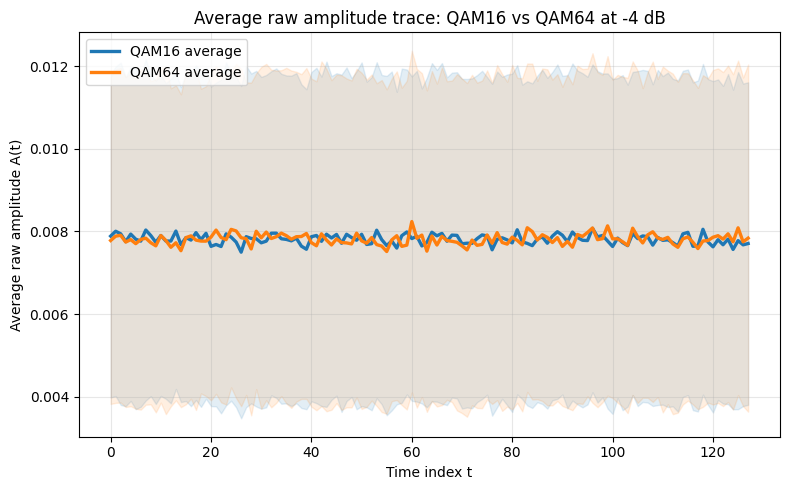

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_04db_average_raw_amplitude_time_trace.png


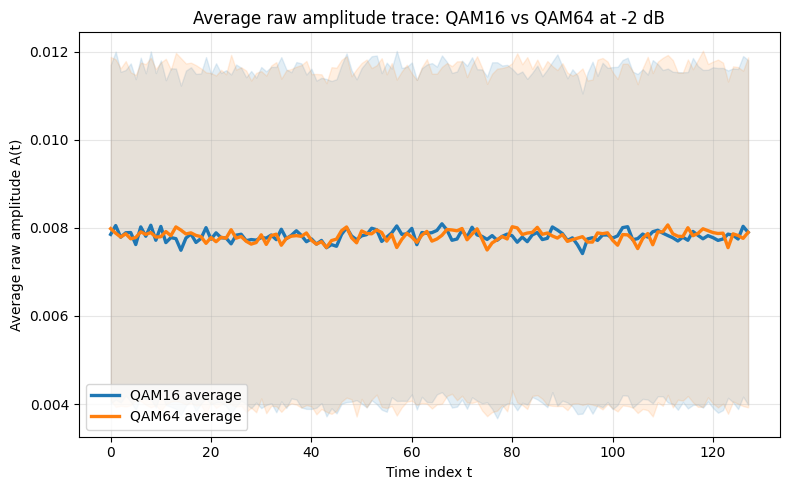

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_minus_02db_average_raw_amplitude_time_trace.png


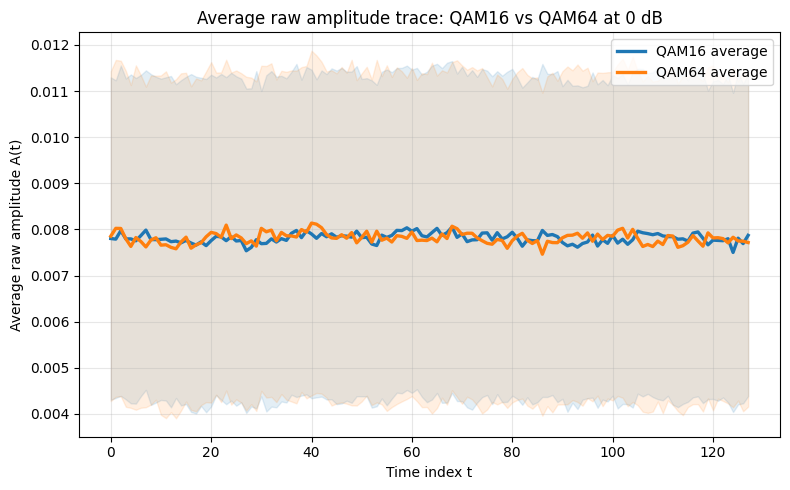

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_00db_average_raw_amplitude_time_trace.png


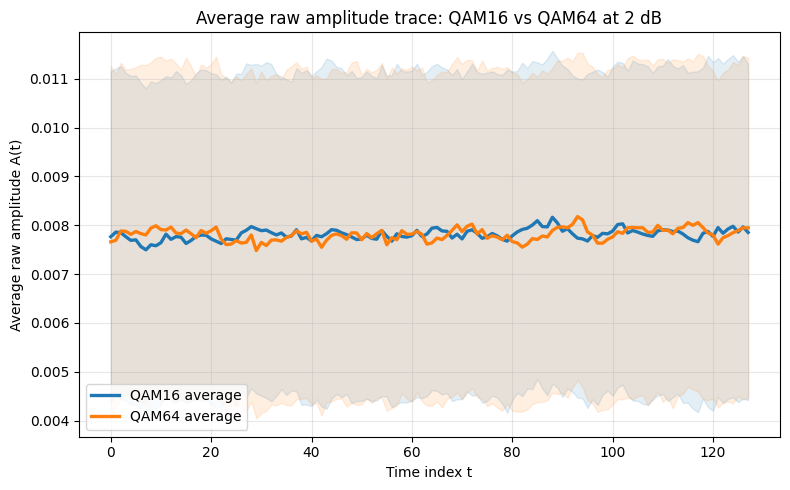

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/snr_plus_02db_average_raw_amplitude_time_trace.png
Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/results/average_raw_amplitude_time_trace_values.csv


,snr_db,modulation,time_index,mean_raw_amplitude,std_raw_amplitude
0,-4,QAM16,0,0.007888,0.003910
1,-4,QAM16,1,0.008006,0.003994
2,-4,QAM16,2,0.007944,0.004148
3,-4,QAM16,3,0.007753,0.003987
4,-4,QAM16,4,0.007937,0.004044


In [10]:
# CELL 10: Average raw time-domain amplitude A(t) overlays for QAM16 vs QAM64
raw_at_rows = []

for snr in TARGET_SNRS:
    fig, ax = plt.subplots(figsize=(8, 5))

    for mod in TARGET_MODS:
        A = amp_raw[(mod, snr)]
        mean_curve = A.mean(axis=0)
        std_curve = A.std(axis=0)

        ax.plot(time_idx, mean_curve, color=COLORS[mod], linewidth=2.4, label=f"{mod} average")
        ax.fill_between(time_idx, mean_curve - std_curve, mean_curve + std_curve, color=COLORS[mod], alpha=0.12)

        for t, mean_value, std_value in zip(time_idx, mean_curve, std_curve):
            raw_at_rows.append({
                "snr_db": snr,
                "modulation": mod,
                "time_index": int(t),
                "mean_raw_amplitude": float(mean_value),
                "std_raw_amplitude": float(std_value),
            })

    ax.set_title(f"Average raw amplitude trace: QAM16 vs QAM64 at {snr} dB")
    ax.set_xlabel("Time index t")
    ax.set_ylabel("Average raw amplitude A(t)")
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()
    out_path = FIG_DIR / f"{safe_snr_name(snr)}_average_raw_amplitude_time_trace.png"
    fig.savefig(out_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")

raw_at_df = pd.DataFrame(raw_at_rows)
raw_at_csv = RESULT_DIR / "average_raw_amplitude_time_trace_values.csv"
raw_at_df.to_csv(raw_at_csv, index=False)
print(f"Saved: {raw_at_csv}")
display(raw_at_df.head())

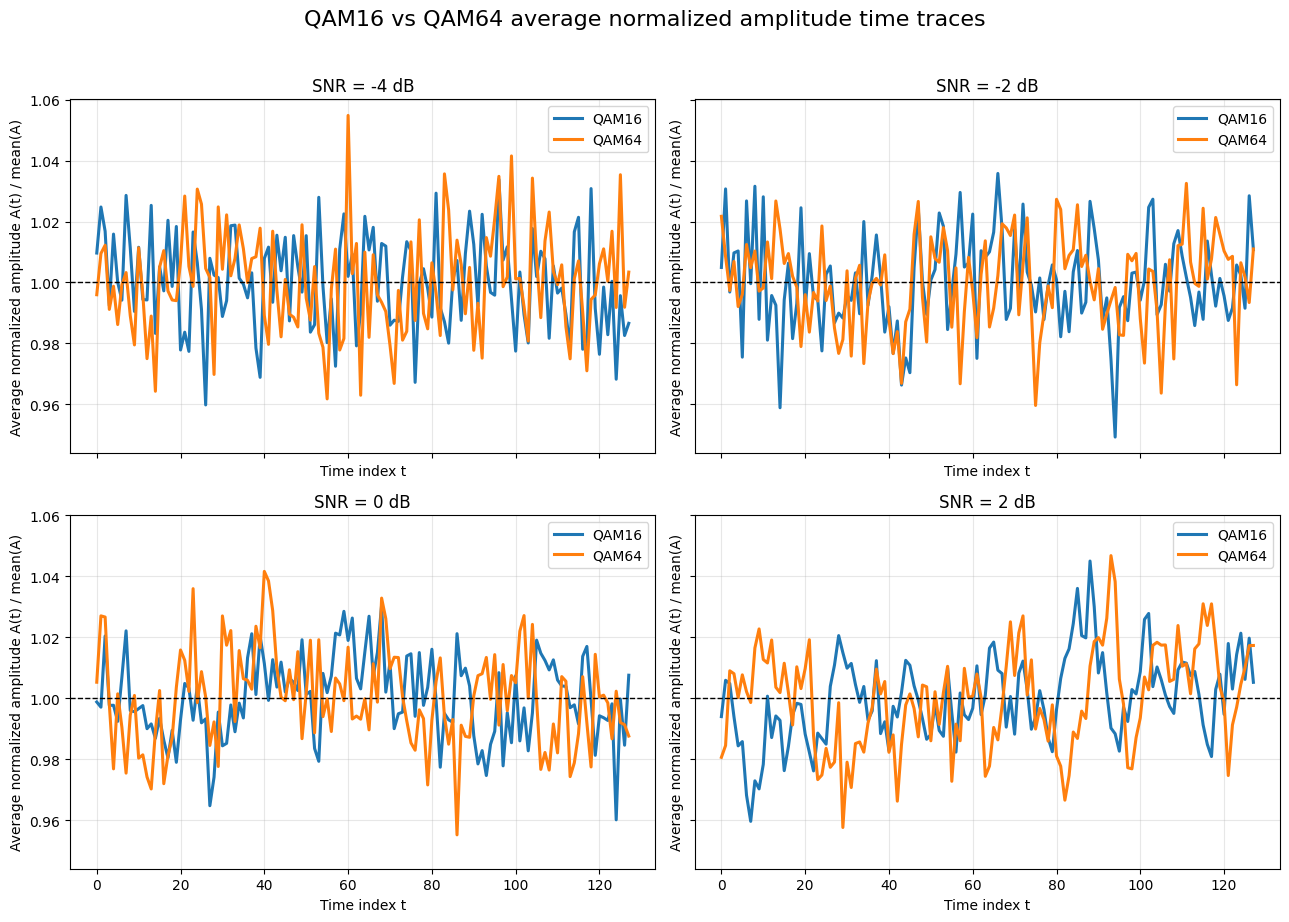

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/all_target_snrs_average_normalized_amplitude_time_traces.png


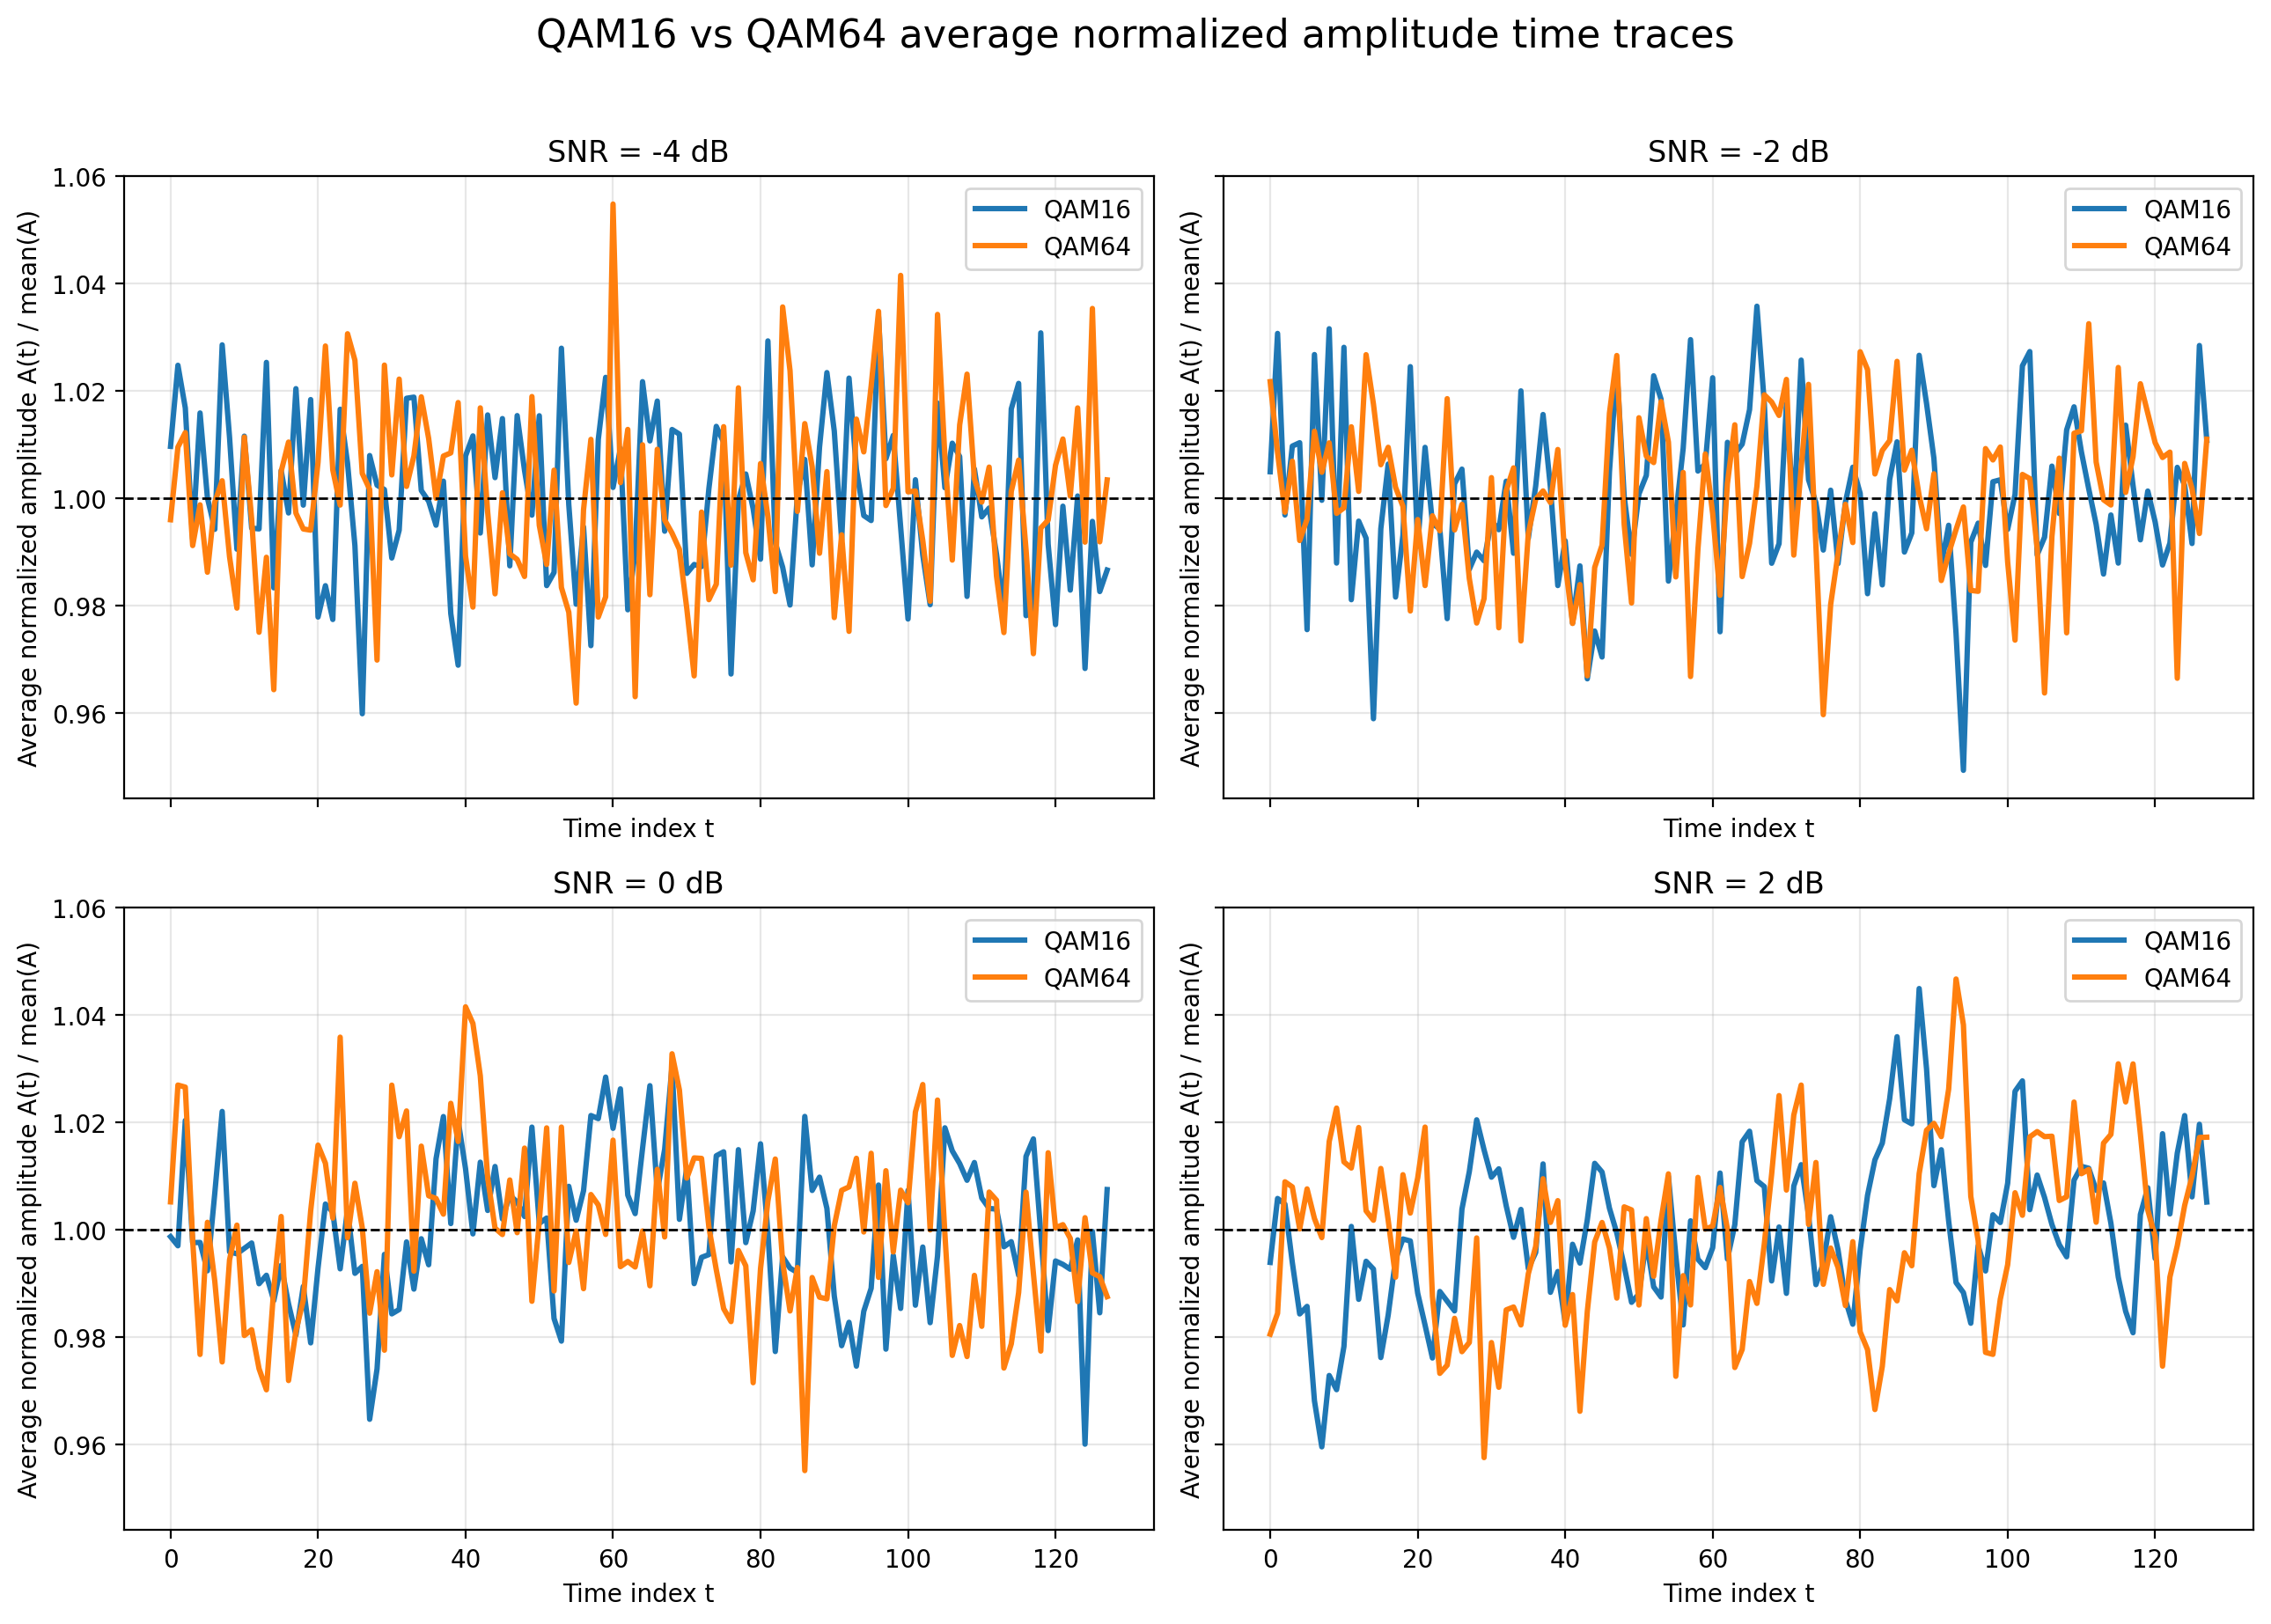

In [11]:
# CELL 11: Combined average time-domain normalized amplitude A(t) overlays for all target SNRs
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, snr in zip(axes, TARGET_SNRS):
    for mod in TARGET_MODS:
        A = amp_norm[(mod, snr)]
        mean_curve = A.mean(axis=0)
        ax.plot(time_idx, mean_curve, color=COLORS[mod], linewidth=2.2, label=mod)

    ax.axhline(1.0, color="black", linestyle="--", linewidth=1.0)
    ax.set_title(f"SNR = {snr} dB")
    ax.set_xlabel("Time index t")
    ax.set_ylabel("Average normalized amplitude A(t) / mean(A)")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("QAM16 vs QAM64 average normalized amplitude time traces", fontsize=16, y=1.02)
fig.tight_layout()
combined_at_path = FIG_DIR / "all_target_snrs_average_normalized_amplitude_time_traces.png"
fig.savefig(combined_at_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {combined_at_path}")

display(Image(filename=str(combined_at_path)))

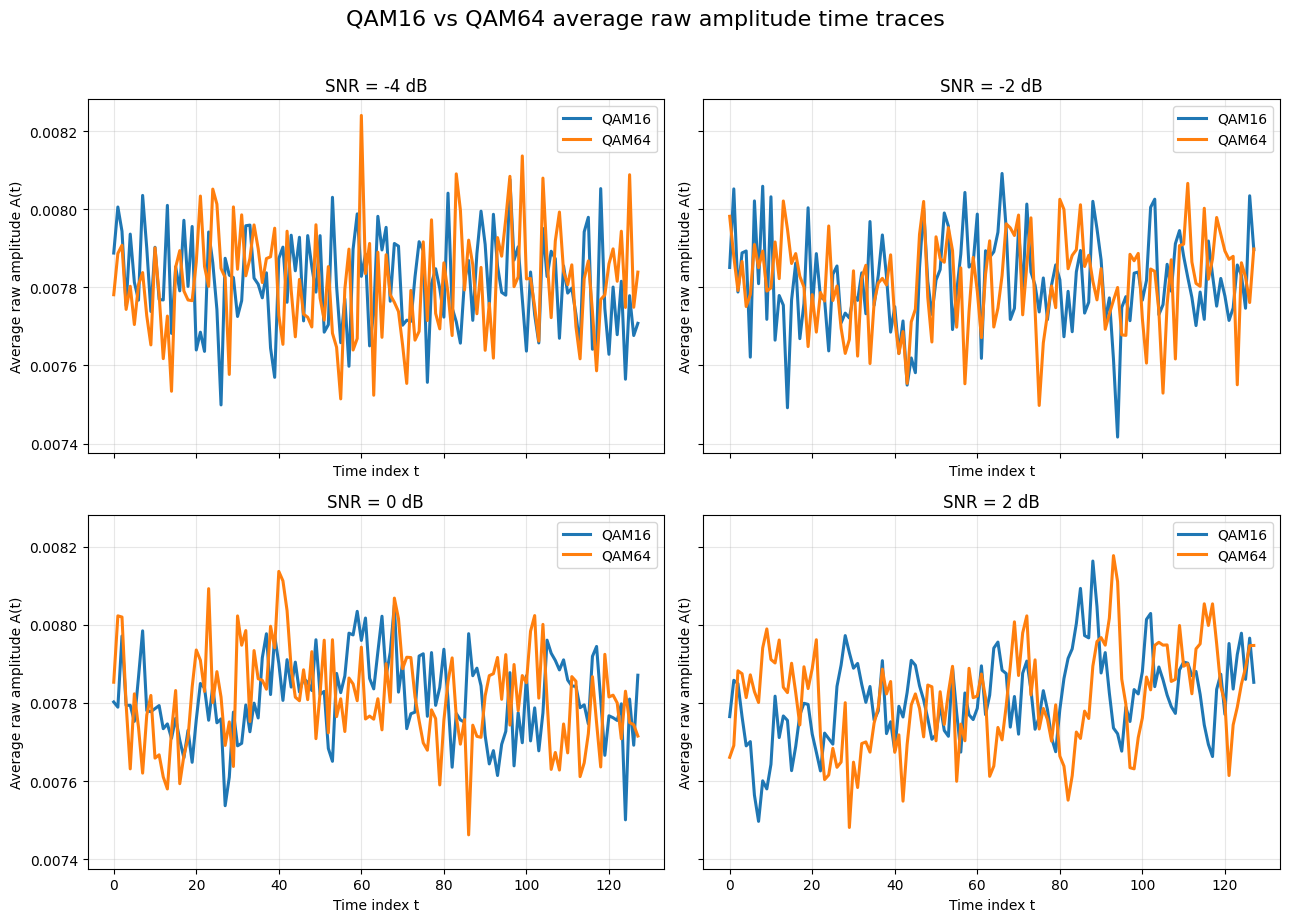

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/all_target_snrs_average_raw_amplitude_time_traces.png


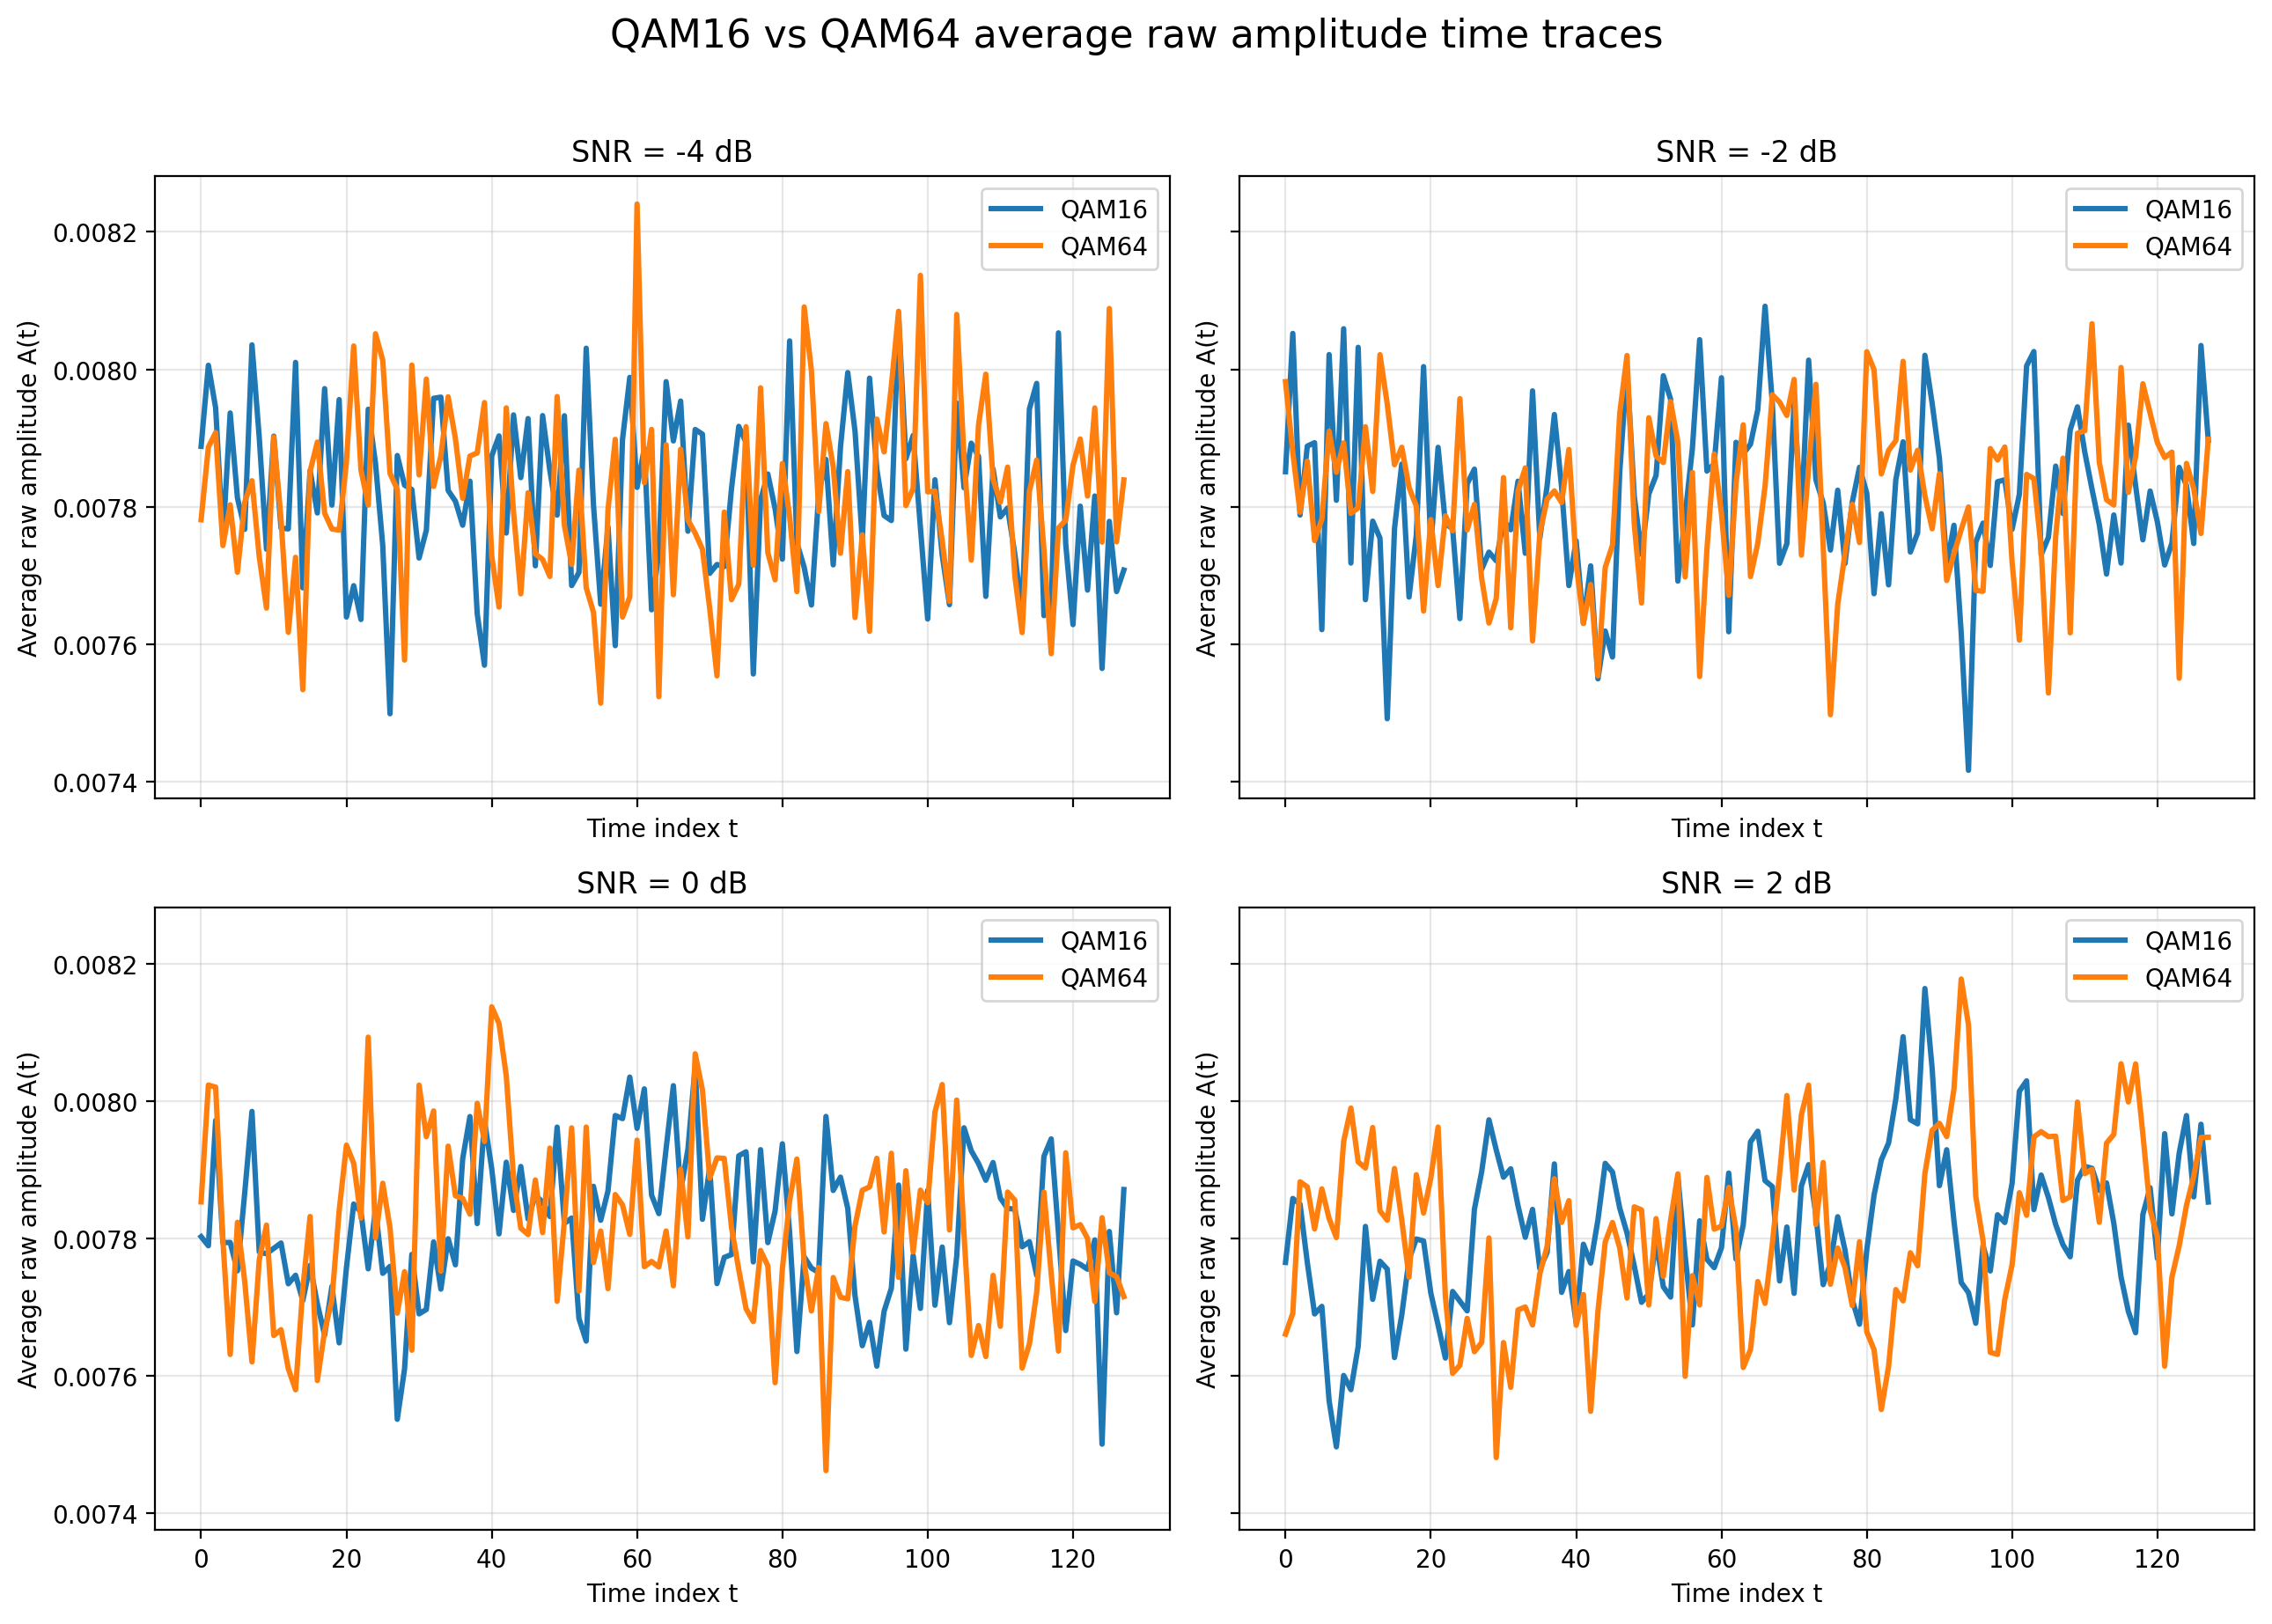

In [12]:
# CELL 12: Combined average raw time-domain amplitude A(t) overlays for all target SNRs
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, snr in zip(axes, TARGET_SNRS):
    for mod in TARGET_MODS:
        A = amp_raw[(mod, snr)]
        mean_curve = A.mean(axis=0)
        ax.plot(time_idx, mean_curve, color=COLORS[mod], linewidth=2.2, label=mod)

    ax.set_title(f"SNR = {snr} dB")
    ax.set_xlabel("Time index t")
    ax.set_ylabel("Average raw amplitude A(t)")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("QAM16 vs QAM64 average raw amplitude time traces", fontsize=16, y=1.02)
fig.tight_layout()
combined_raw_at_path = FIG_DIR / "all_target_snrs_average_raw_amplitude_time_traces.png"
fig.savefig(combined_raw_at_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {combined_raw_at_path}")

display(Image(filename=str(combined_raw_at_path)))

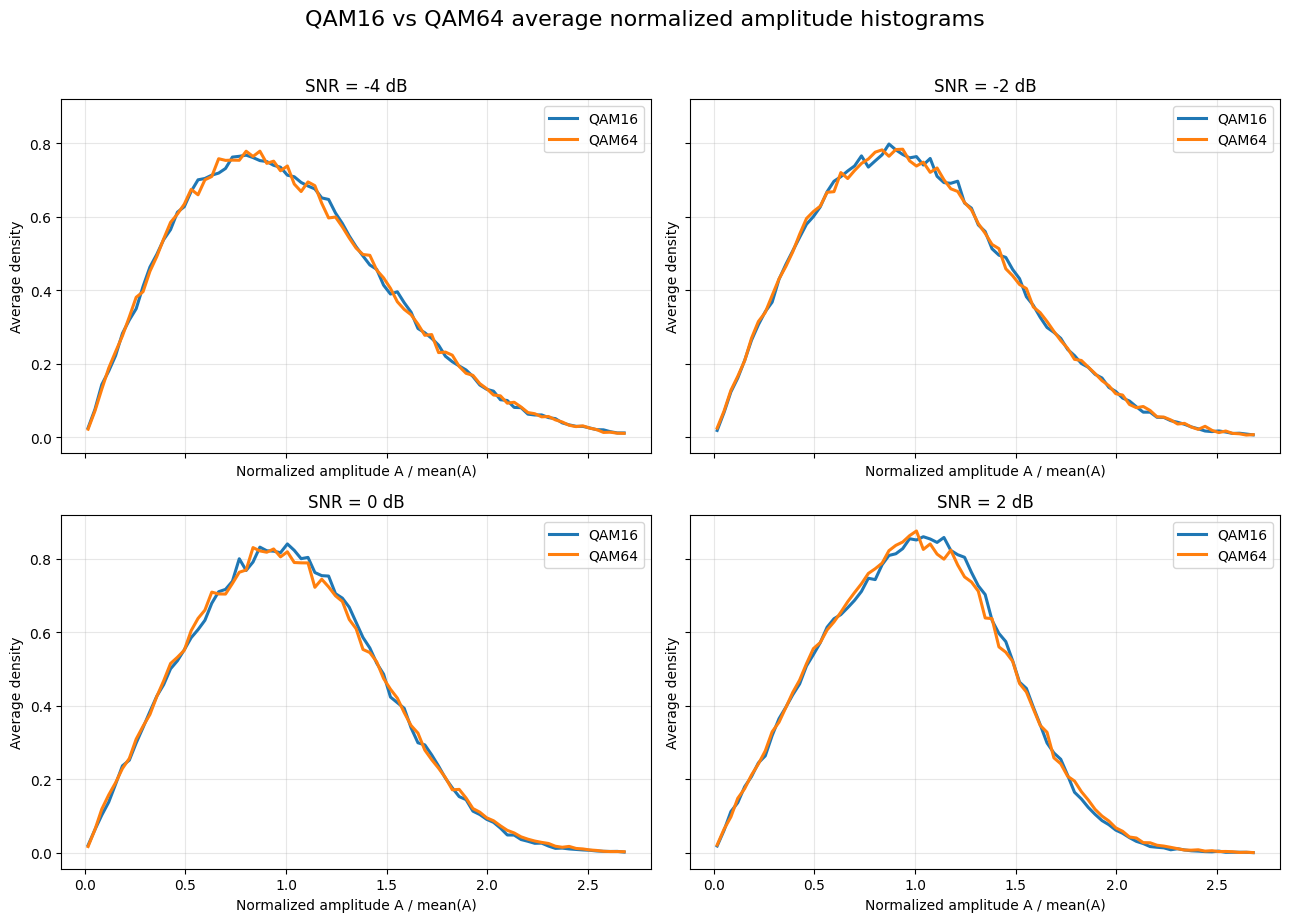

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/all_target_snrs_average_normalized_overlay.png


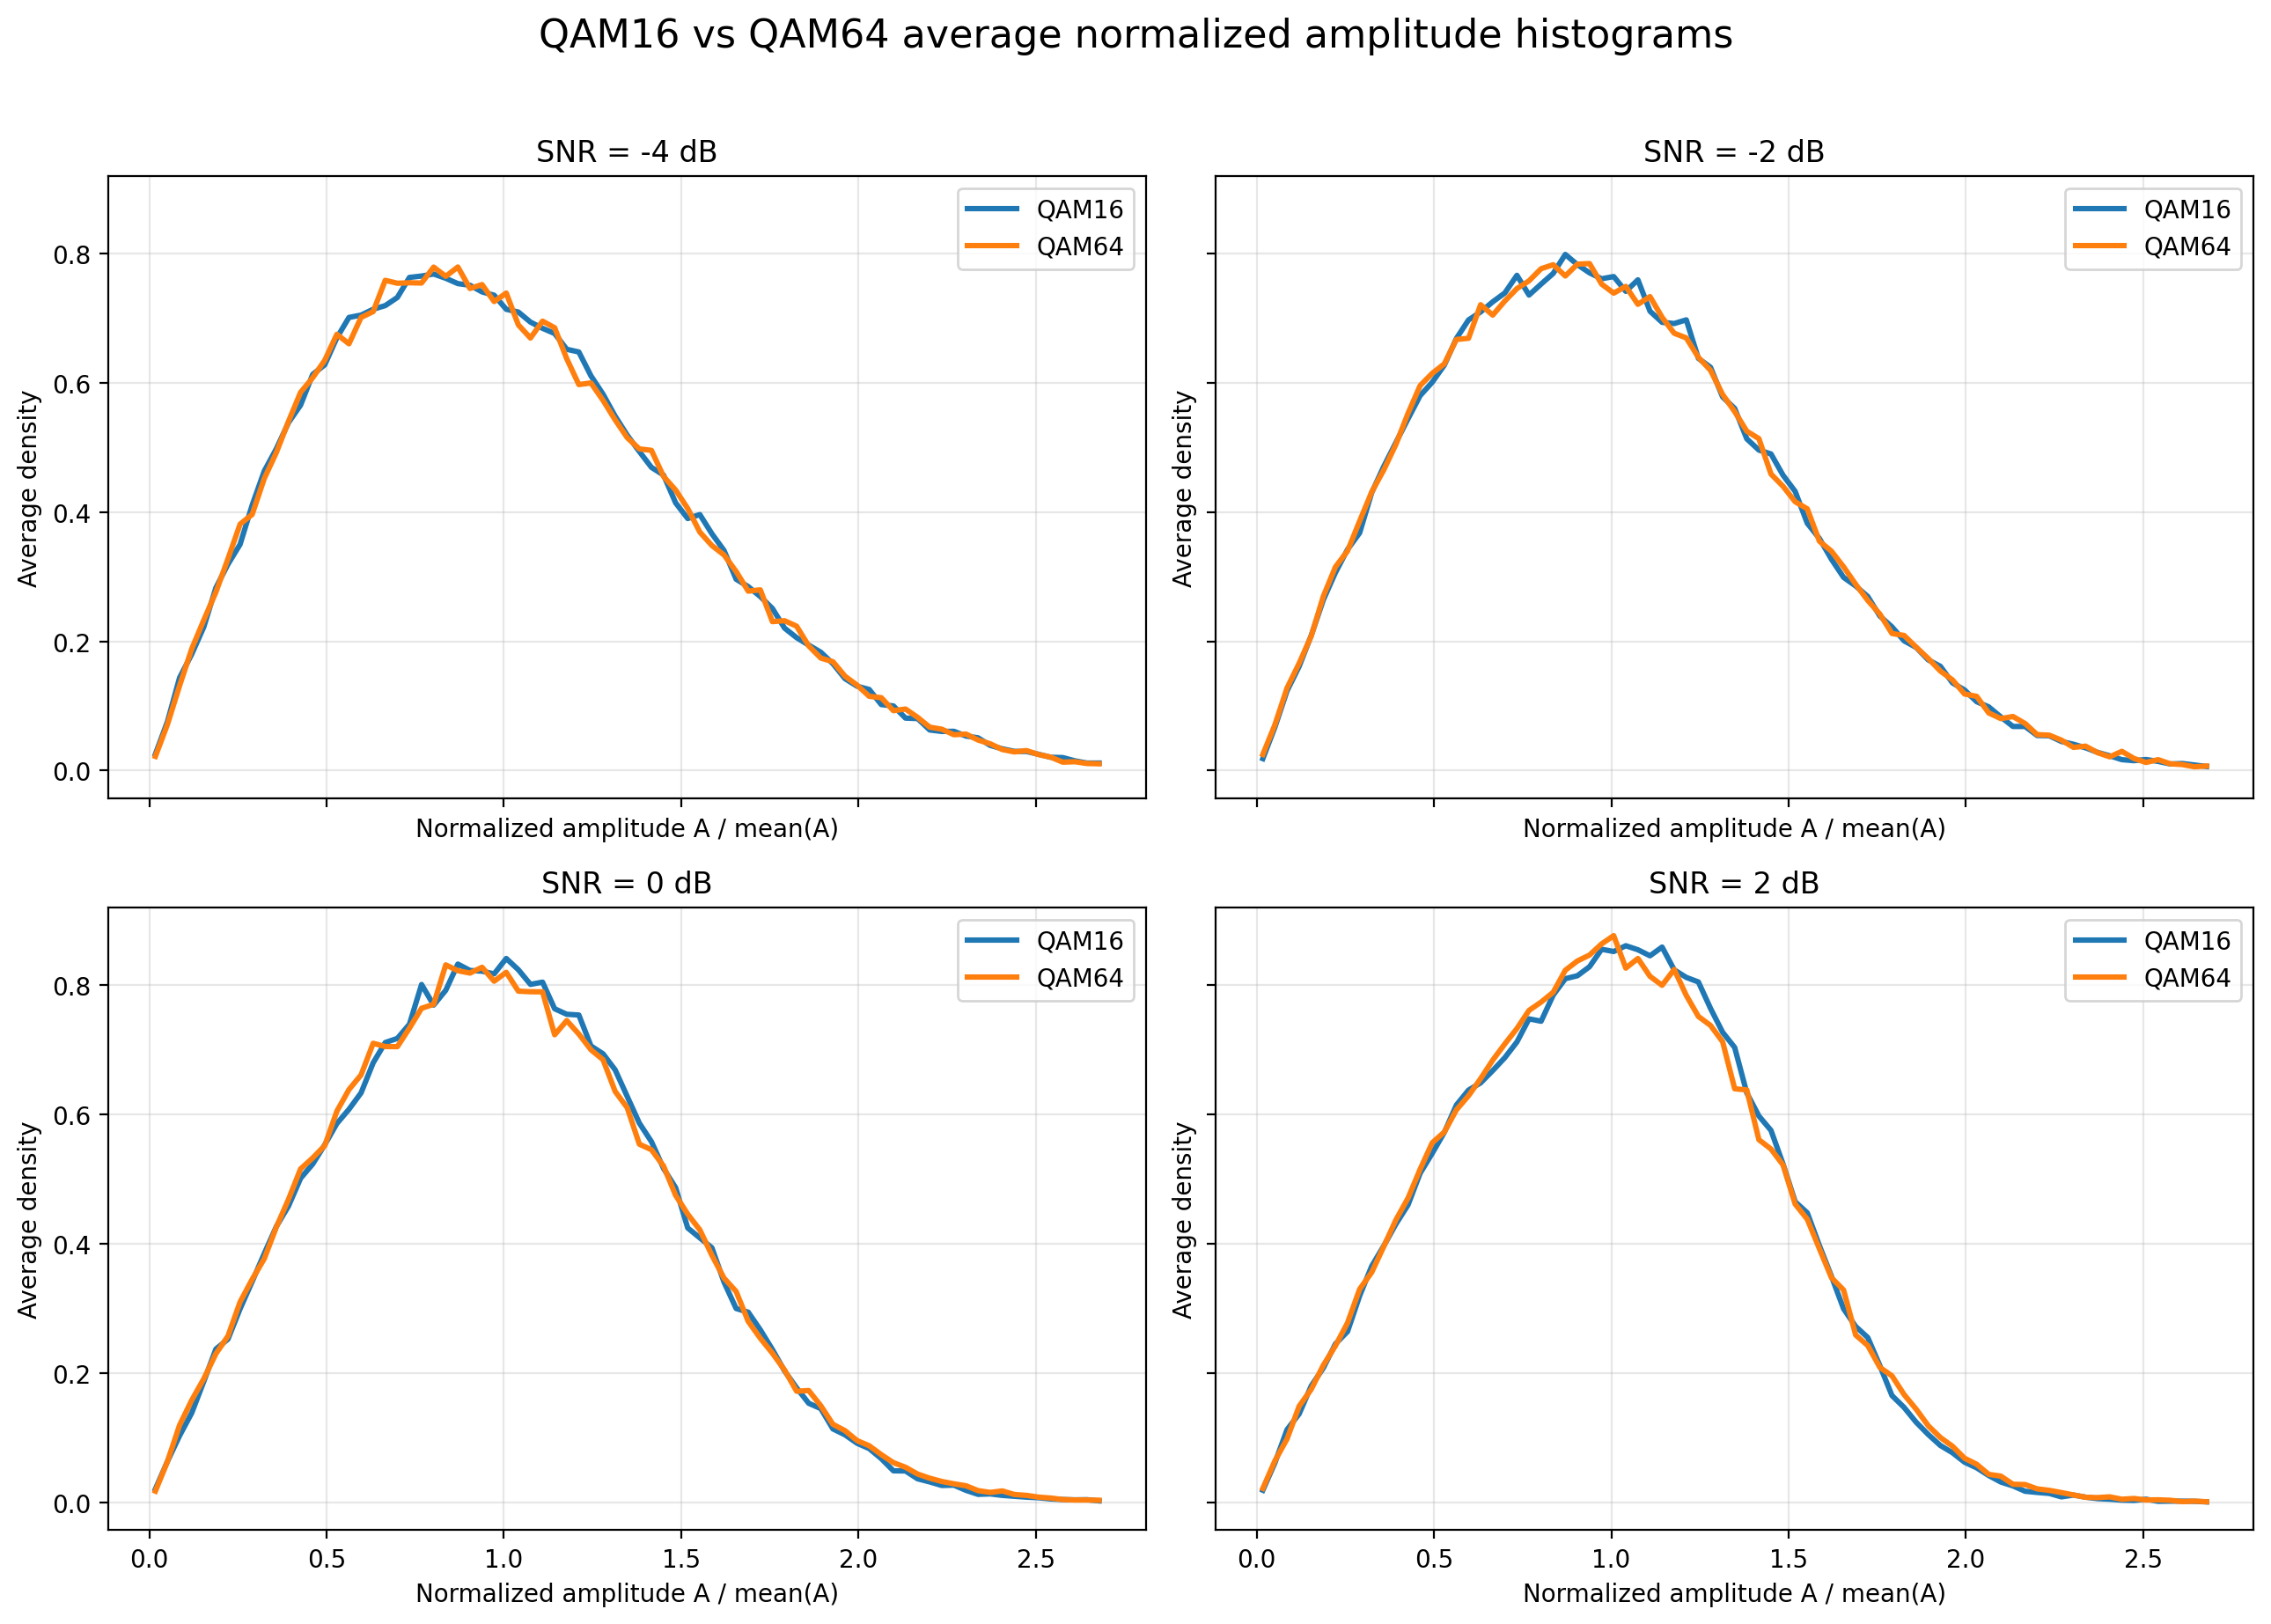

In [13]:
# CELL 13: Combined average normalized overlay for all target SNRs
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, snr in zip(axes, TARGET_SNRS):
    for mod in TARGET_MODS:
        H = per_sample_histograms(amp_norm[(mod, snr)], norm_bins)
        mean_h = H.mean(axis=0)
        ax.plot(centers, mean_h, color=COLORS[mod], linewidth=2.2, label=mod)

    ax.set_title(f"SNR = {snr} dB")
    ax.set_xlabel("Normalized amplitude A / mean(A)")
    ax.set_ylabel("Average density")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("QAM16 vs QAM64 average normalized amplitude histograms", fontsize=16, y=1.02)
fig.tight_layout()
combined_path = FIG_DIR / "all_target_snrs_average_normalized_overlay.png"
fig.savefig(combined_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {combined_path}")

display(Image(filename=str(combined_path)))

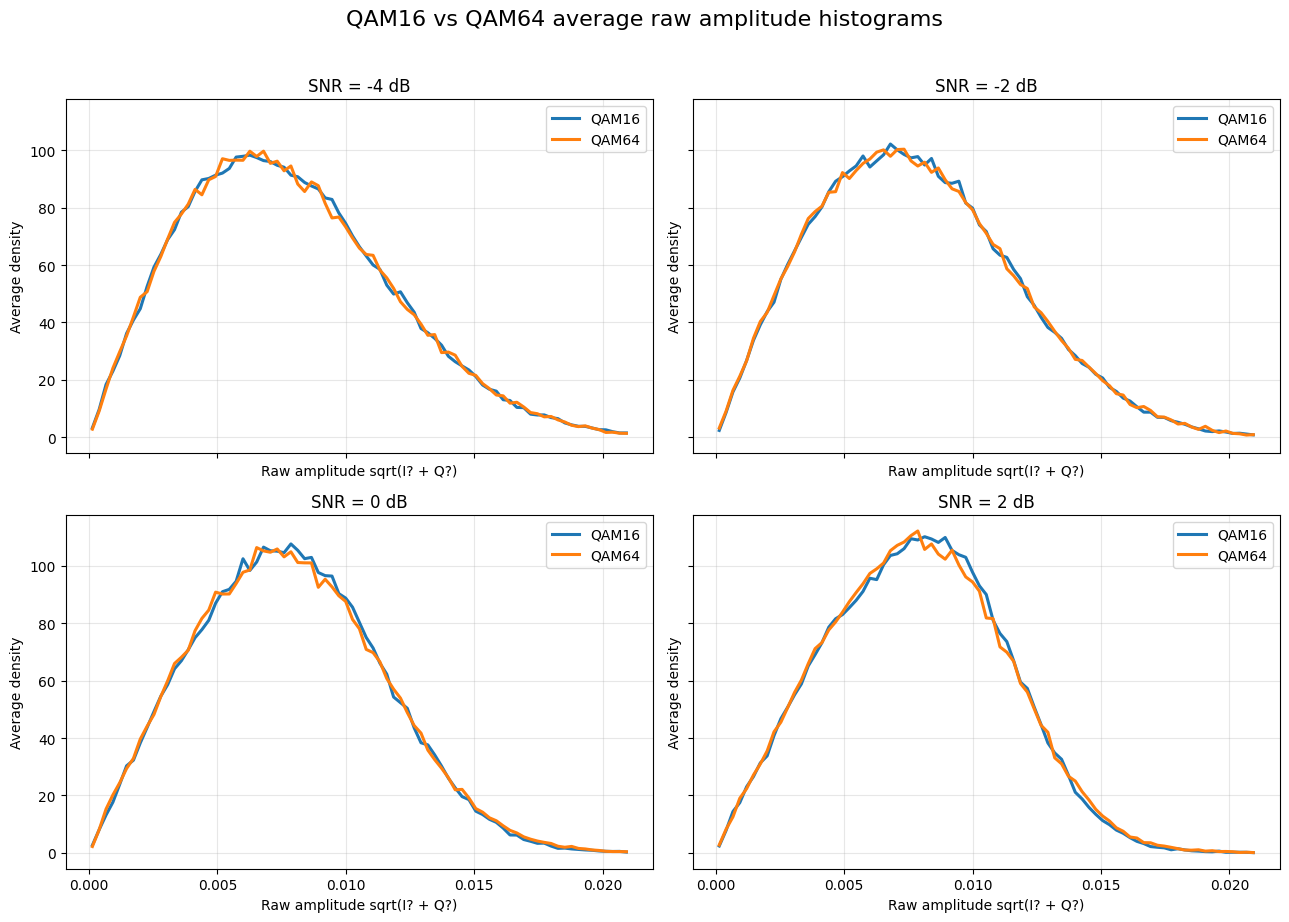

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/figures/all_target_snrs_average_raw_overlay.png


In [14]:
# CELL 14: Optional raw-amplitude average overlays
# These are saved for reference. The normalized plots are usually the main comparison.
raw_centers = 0.5 * (raw_bins[:-1] + raw_bins[1:])

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
axes = axes.ravel()

for ax, snr in zip(axes, TARGET_SNRS):
    for mod in TARGET_MODS:
        H = per_sample_histograms(amp_raw[(mod, snr)], raw_bins)
        ax.plot(raw_centers, H.mean(axis=0), color=COLORS[mod], linewidth=2.2, label=mod)

    ax.set_title(f"SNR = {snr} dB")
    ax.set_xlabel("Raw amplitude sqrt(I? + Q?)")
    ax.set_ylabel("Average density")
    ax.grid(True, alpha=0.3)
    ax.legend()

fig.suptitle("QAM16 vs QAM64 average raw amplitude histograms", fontsize=16, y=1.02)
fig.tight_layout()
raw_combined_path = FIG_DIR / "all_target_snrs_average_raw_overlay.png"
fig.savefig(raw_combined_path, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {raw_combined_path}")

In [15]:
# CELL 15: Write a small output README
readme_text = f"""
QAM16 vs QAM64 amplitude histogram analysis

Target SNR values: {TARGET_SNRS} dB
Random samples per modulation/SNR: {N_RANDOM_SAMPLES}
Random seed: {RANDOM_SEED}

Main figures:
- figures/*_random_3_samples_normalized_histograms.png
  Random single-window normalized amplitude histograms.
- figures/*_random_3_samples_normalized_amplitude_time_traces.png
  Random single-window normalized amplitude A(t)/mean(A) time traces.
- figures/*_random_3_samples_raw_amplitude_time_traces.png
  Random single-window raw amplitude A(t) time traces.
- figures/*_average_normalized_overlay.png
  Average normalized amplitude histogram overlay for QAM16 vs QAM64 at one SNR.
- figures/*_average_normalized_amplitude_time_trace.png
  Average normalized amplitude A(t)/mean(A) trace overlay for QAM16 vs QAM64 at one SNR.
- figures/*_average_raw_amplitude_time_trace.png
  Average raw amplitude A(t) trace overlay for QAM16 vs QAM64 at one SNR.
- figures/all_target_snrs_average_normalized_overlay.png
  Combined average normalized histogram overlays for all target SNRs.
- figures/all_target_snrs_average_normalized_amplitude_time_traces.png
  Combined average normalized amplitude A(t)/mean(A) trace overlays for all target SNRs.
- figures/all_target_snrs_average_raw_amplitude_time_traces.png
  Combined average raw amplitude A(t) trace overlays for all target SNRs.
- figures/all_target_snrs_average_raw_overlay.png
  Combined raw-amplitude overlays for reference.

Main tables:
- results/selected_random_samples.csv
  Exact randomly selected sample indices inside each RML2016.10a modulation/SNR block.
- results/amplitude_summary_statistics.csv
  Mean/std/p95/p99/PAR summary values.
- results/average_normalized_histogram_values.csv
  Average normalized histogram density values for reproducible plotting.
- results/average_normalized_amplitude_time_trace_values.csv
  Average normalized A(t)/mean(A) values for reproducible time-trace plotting.
- results/average_raw_amplitude_time_trace_values.csv
  Average raw A(t) values for reproducible time-trace plotting.
- results/histogram_settings.json
  Bins, seed, and normalization details.

Normalization:
1. Per-window RMS normalization of IQ.
2. A(t) = sqrt(I(t)^2 + Q(t)^2).
3. A_norm(t) = A(t) / mean(A(t)) per 128-sample window.
""".strip()

readme_path = EXP_DIR / "README_qam_amplitude_histograms.txt"
readme_path.write_text(readme_text)
print(f"Saved: {readme_path}")

Saved: /kaggle/working/amr-5-class/experiments/qam_amplitude_histograms/README_qam_amplitude_histograms.txt


In [16]:
# CELL 16: Zip figures and tables for download
stamp = datetime.now().strftime("%Y%m%d_%H%M")
zip_base = Path("/kaggle/working") / f"qam_amplitude_histograms_{stamp}"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=str(EXP_DIR))

print("Export complete")
print(f"Zip file: {zip_path}")
print("\nFiles included:")
for p in sorted(EXP_DIR.rglob("*")):
    if p.is_file():
        print(" -", p.relative_to(EXP_DIR))

try:
    from IPython.display import FileLink
    display(FileLink(zip_path))
except Exception:
    pass

Export complete
Zip file: /kaggle/working/qam_amplitude_histograms_20260629_1355.zip

Files included:
 - README_qam_amplitude_histograms.txt
 - figures/all_target_snrs_average_normalized_amplitude_time_traces.png
 - figures/all_target_snrs_average_normalized_overlay.png
 - figures/all_target_snrs_average_raw_amplitude_time_traces.png
 - figures/all_target_snrs_average_raw_overlay.png
 - figures/snr_minus_02db_average_normalized_amplitude_time_trace.png
 - figures/snr_minus_02db_average_normalized_overlay.png
 - figures/snr_minus_02db_average_raw_amplitude_time_trace.png
 - figures/snr_minus_02db_random_3_samples_normalized_amplitude_time_traces.png
 - figures/snr_minus_02db_random_3_samples_normalized_histograms.png
 - figures/snr_minus_02db_random_3_samples_raw_amplitude_time_traces.png
 - figures/snr_minus_04db_average_normalized_amplitude_time_trace.png
 - figures/snr_minus_04db_average_normalized_overlay.png
 - figures/snr_minus_04db_average_raw_amplitude_time_trace.png
 - figures/

/kaggle/working/qam_amplitude_histograms_20260629_1355.zip